# Ce/Yb CIF → PyCrystalField Stevens Parameters → Field-Transition Estimates

This notebook downloads CIF files for the target Ce/Yb compounds, estimates Stevens parameters using PyCrystalField point-charge modeling, and builds a table of candidate field-energy scales for \(D_2\), \(D_3\), and \(D_4\) phase-transition/avoided-crossing estimates.

**Important:** PyCrystalField-from-CIF values are point-charge estimates, not fitted experimental CEF parameters. Treat the output as a screening workflow.

In [1]:
# Optional installs if needed
# !pip install mp-api pymatgen pandas numpy sympy tqdm
# !pip install git+https://github.com/asche1/PyCrystalField.git@master

In [1]:
from __future__ import annotations
import os, re, json
from pathlib import Path
from typing import Dict, Any, Optional, List
import numpy as np
import pandas as pd
import sympy as sp
from tqdm.auto import tqdm
from pymatgen.io.cif import CifWriter

/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Compound list

In [ ]:
COMPOUNDS = [
    {"idx": 1,  "formula": "CeIn3",       "mag_ion": "Ce", "note": "Cubic benchmark compound; initial test case."},
    {"idx": 2,  "formula": "CeCoIn5",     "mag_ion": "Ce", "note": "Ce-115 heavy-fermion superconductor."},
    {"idx": 3,  "formula": "CeRhIn5",     "mag_ion": "Ce", "note": "Ce-115 antiferromagnet / quantum critical."},
    {"idx": 4,  "formula": "CeIrIn5",     "mag_ion": "Ce", "note": "Ce-115 heavy-fermion superconductor."},
    {"idx": 5,  "formula": "Ce2RhIn8",    "mag_ion": "Ce", "note": "Layered Ce-In homologous compound."},
    {"idx": 6,  "formula": "Ce2IrIn8",    "mag_ion": "Ce", "note": "Layered Ce-In homologous compound."},
    {"idx": 7,  "formula": "CePt2In7",    "mag_ion": "Ce", "note": "More two-dimensional analogue of CeIn3."},
    {"idx": 8,  "formula": "Ce2CoAl7Ge4", "mag_ion": "Ce", "note": "Ronning-linked Ce heavy-fermion compound."},
    {"idx": 9,  "formula": "Ce2IrAl7Ge4", "mag_ion": "Ce", "note": "Ce2MAl7Ge4 family."},
    {"idx": 10, "formula": "Ce2NiAl7Ge4", "mag_ion": "Ce", "note": "Ce2MAl7Ge4 family."},
    {"idx": 11, "formula": "Ce2PdAl7Ge4", "mag_ion": "Ce", "note": "Ce2MAl7Ge4 family; possible NFL behavior."},
    {"idx": 12, "formula": "CeRhAl4Si2",  "mag_ion": "Ce", "note": "Tetragonal Ce compound."},
    {"idx": 13, "formula": "CeIrAl4Si2",  "mag_ion": "Ce", "note": "CeMAl4Si2 family."},
    {"idx": 14, "formula": "CePtAl4Si2",  "mag_ion": "Ce", "note": "CeMAl4Si2 family."},
    {"idx": 15, "formula": "CePtAl4Ge2",  "mag_ion": "Ce", "note": "Related quaternary heavy-fermion compound."},
    {"idx": 16, "formula": "CeRhSn",      "mag_ion": "Ce", "note": "Anisotropic or mixed-valence Ce compound."},
    {"idx": 17, "formula": "CeIr3B2",     "mag_ion": "Ce", "note": "Quasi-one-dimensional Ce Kondo-lattice compound."},
    {"idx": 18, "formula": "CeRh3B2",     "mag_ion": "Ce", "note": "Related Ce boride compound."},
    {"idx": 19, "formula": "CeLiBi2",     "mag_ion": "Ce", "note": "CeTX2-type compound."},
    {"idx": 20, "formula": "Ce3Cd2As6",   "mag_ion": "Ce", "note": "Ce-based narrow-gap compound."},
    {"idx": 21, "formula": "CeCd3As3",    "mag_ion": "Ce", "note": "Ce triangular-lattice antiferromagnet."},
    {"idx": 22, "formula": "Ce3Bi4Pd3",   "mag_ion": "Ce", "note": "Ce-based correlated/narrow-gap system."},
    {"idx": 23, "formula": "Ce2PdIn8",    "mag_ion": "Ce", "note": "Layered Ce-In heavy-fermion compound."},
    {"idx": 24, "formula": "Ce3PdIn11",   "mag_ion": "Ce", "note": "Layered Ce-In heavy-fermion compound."},
    {"idx": 25, "formula": "YbFe5P3",     "mag_ion": "Yb", "note": "Yb-based comparison case."},
]

def safe_formula_name(formula):
    return re.sub(r"[^A-Za-z0-9_\-]+", "", formula)

for c in COMPOUNDS:
    c["safe_name"] = safe_formula_name(c["formula"])

pd.DataFrame(COMPOUNDS)

,idx,formula,mag_ion,note,safe_name
0,1,CeIn3,Ce,Cubic benchmark compound; initial test case.,CeIn3
1,2,CeCoIn5,Ce,Ce-115 heavy-fermion superconductor.,CeCoIn5
2,3,CeRhIn5,Ce,Ce-115 antiferromagnet / quantum critical.,CeRhIn5
3,4,CeIrIn5,Ce,Ce-115 heavy-fermion superconductor.,CeIrIn5
4,5,Ce2RhIn8,Ce,Layered Ce-In homologous compound.,Ce2RhIn8
5,6,Ce2IrIn8,Ce,Layered Ce-In homologous compound.,Ce2IrIn8
6,7,CePt2In7,Ce,More two-dimensional analogue of CeIn3.,CePt2In7
7,8,Ce2CoAl7Ge4,Ce,Ronning-linked Ce heavy-fermion compound.,Ce2CoAl7Ge4
8,9,Ce2IrAl7Ge4,Ce,Ce2MAl7Ge4 family.,Ce2IrAl7Ge4
9,10,Ce2NiAl7Ge4,Ce,Ce2MAl7Ge4 family.,Ce2NiAl7Ge4


In [2]:
import re
import pandas as pd

RARE_EARTH_FORMULAS = [
    # ========================================================
    # Ce 4f1 heavy fermion / Kondo / CEF systems
    # ========================================================

    # Ce-In cubic / 115 / 218 / 127 / related layered families
    "CeIn3",
    "CeCoIn5", "CeRhIn5", "CeIrIn5",
    "Ce2CoIn8", "Ce2RhIn8", "Ce2IrIn8", "Ce2PdIn8",
    "Ce3PdIn11", "CePt2In7",

    # Ce-122 ThCr2Si2-type / related tetragonal systems
    "CeCu2Si2", "CeCu2Ge2",
    "CeRu2Si2", "CeRh2Si2", "CePd2Si2", "CeNi2Ge2",
    "CeAg2Si2", "CeAu2Si2", "CeIr2Si2", "CePt2Si2",
    "CeCo2Si2", "CeCo2Ge2", "CeRh2Ge2", "CePd2Ge2",

    # CeCu6 / CeAl3 / classic Kondo lattice systems
    "CeAl3",
    "CeCu6", "CeCu5Au", "CeCu6Au",
    "CeCu5Ag", "CeCu5Pd", "CeCu5Pt",

    # Ce hexaborides / skutterudite-like / cubic systems
    "CeB6", "Ce3Bi4Pt3", "Ce3Bi4Pd3",

    # CeTX2 / 112-type pnictides
    "CeAgSb2", "CeAuSb2",
    "CeCuBi2", "CeNiBi2", "CePdBi2", "CePtBi2",
    "CeAgBi2", "CeAuBi2",
    "CeCuSb2", "CeNiSb2", "CePdSb2", "CePtSb2",

    # Noncentrosymmetric CeTX3 systems
    "CeCoGe3", "CeRhGe3", "CeIrGe3",
    "CeCoSi3", "CeRhSi3", "CeIrSi3", "CePtSi3",
    "CeRuSi3", "CeOsSi3",

    # CeTAl4X2 and related quaternaries
    "CeRhAl4Si2", "CeIrAl4Si2", "CePtAl4Si2",
    "CeRhAl4Ge2", "CeIrAl4Ge2", "CePtAl4Ge2",

    # Ce2TAl7Ge4 family
    "Ce2CoAl7Ge4", "Ce2IrAl7Ge4",
    "Ce2NiAl7Ge4", "Ce2PdAl7Ge4",

    # CeRhSn / frustrated / anisotropic systems
    "CeRhSn", "CeIrSn", "CeCoSn", "CeNiSn", "CeRuSn",

    # Ce borides / quasi-1D borides
    "CeIr3B2", "CeRh3B2", "CeCo3B2",

    # Ce-based arsenides / triangular / narrow-gap systems
    "CeCd3As3", "Ce3Cd2As6",
    "CeZn3As3", "Ce3Zn2As6",
    "CeLiBi2",

    # CePt/Sb/Bi half-Heusler or related systems
    "CePtBi", "CePdBi", "CeNiBi",
    "CeAuBi", "CeAgBi",

    # Additional Ce intermetallic Kondo-lattice candidates
    "CePd3", "CeSn3", "CeInCu2", "CePdAl",
    "CeCuAl3", "CeAuAl3", "CePdAl3", "CePtAl3",
    "CeNiAl4", "CeCuAl4", "CeRu2Al10", "CeOs2Al10",
    "CeFe2Al10", "CeT2Al10",

    # Yb heavy fermion / intermediate valence systems
    "YbRh2Si2", "YbCo2Zn20", "YbIr2Zn20", "YbFe2Zn20", "YbAl3",
    "YbAl2", "YbCu2Si2", "YbCu2Ge2", "YbNi2Ge2", "YbAgGe",
    "YbPtBi", "YbBiPt", "YbB12", "YbInCu4", "YbCu5Al", "YbCu4Ag",
    "YbAuCu4", "YbPdCu4", "YbFe5P3", "YbMn2Sb2", "YbMgGaO4",
    "YbTi2Zn20", "YbCo2Si2", "YbRh3Si7", "YbNi4P2",

    # Pr f-electron / quadrupolar systems
    "PrOs4Sb12", "PrRu4Sb12", "PrFe4P12", "PrV2Al20", "PrTi2Al20",
    "PrIr2Zn20", "PrRh2Zn20", "PrPb3", "PrInAg2", "PrNi5",
    "PrCu2", "PrAg2In", "PrMg3", "PrB6", "PrCoIn5", "PrRhIn5",
    "PrIrIn5", "PrIn3",

    # Nd systems
    "NdIn3", "NdCoIn5", "NdRhIn5", "NdIrIn5", "NdB6", "NdCu2",
    "NdCu2Si2", "NdCu2Ge2", "NdRu2Si2", "NdRh2Si2", "NdNi2Ge2",
    "NdPd2Si2", "NdAgSb2", "NdAuSb2", "NdPtBi", "NdBiPt",

    # Sm systems
    "SmB6", "SmS", "SmSe", "SmTe", "SmOs4Sb12", "SmRu4P12",
    "SmFe4P12", "SmIn3", "SmCu2Si2", "SmCu2Ge2", "SmRh2Si2",
    "SmIr2Si2", "SmPt2Si2", "SmAgSb2", "SmAuSb2",

    # Eu systems
    "EuB6", "EuIn2As2", "EuCd2As2", "EuCd2Sb2", "EuZn2As2",
    "EuZn2Sb2", "EuFe2As2", "EuCo2As2", "EuRh2As2", "EuGa4",
    "EuAl4", "EuPd2Si2", "EuNi2P2", "EuCu2Si2",

    # Gd systems
    "GdIn3", "GdB6", "GdCu2", "GdCu2Si2", "GdCu2Ge2", "GdRh2Si2",
    "GdIr2Si2", "GdPt2Si2", "GdAgSb2", "GdAuSb2", "GdPtBi",
    "GdBiPt", "GdCoIn5", "GdRhIn5", "GdIrIn5",

    # Tb systems
    "TbIn3", "TbB6", "TbCu2", "TbCu2Si2", "TbCu2Ge2", "TbRh2Si2",
    "TbIr2Si2", "TbPt2Si2", "TbAgSb2", "TbAuSb2", "TbPtBi",
    "TbBiPt", "TbCoIn5", "TbRhIn5", "TbIrIn5",

    # Dy systems
    "DyIn3", "DyB6", "DyCu2", "DyCu2Si2", "DyCu2Ge2", "DyRh2Si2",
    "DyIr2Si2", "DyPt2Si2", "DyAgSb2", "DyAuSb2", "DyPtBi",
    "DyBiPt", "DyCoIn5", "DyRhIn5", "DyIrIn5",

    # Ho systems
    "HoIn3", "HoB6", "HoCu2", "HoCu2Si2", "HoCu2Ge2", "HoRh2Si2",
    "HoIr2Si2", "HoPt2Si2", "HoAgSb2", "HoAuSb2", "HoPtBi",
    "HoBiPt", "HoCoIn5", "HoRhIn5", "HoIrIn5",

    # Er systems
    "ErIn3", "ErB6", "ErCu2", "ErCu2Si2", "ErCu2Ge2", "ErRh2Si2",
    "ErIr2Si2", "ErPt2Si2", "ErAgSb2", "ErAuSb2", "ErPtBi",
    "ErBiPt", "ErCoIn5", "ErRhIn5", "ErIrIn5",

    # Tm systems
    "TmIn3", "TmB6", "TmCu2", "TmCu2Si2", "TmCu2Ge2", "TmRh2Si2",
    "TmIr2Si2", "TmPt2Si2", "TmAgSb2", "TmAuSb2", "TmPtBi",
    "TmBiPt", "TmCoIn5", "TmRhIn5", "TmIrIn5",
]

RARE_EARTHS = ["Ce", "Pr", "Nd", "Sm", "Eu", "Gd", "Tb", "Dy", "Ho", "Er", "Tm", "Yb"]

def safe_formula_name(formula):
    return re.sub(r"[^A-Za-z0-9_\-]+", "", formula)

def guess_mag_ion(formula):
    for ion in RARE_EARTHS:
        if formula.startswith(ion):
            return ion
    for ion in RARE_EARTHS:
        if ion in formula:
            return ion
    return None

# remove duplicates while preserving order
seen = set()
unique_formulas = []
for f in RARE_EARTH_FORMULAS:
    if f not in seen:
        unique_formulas.append(f)
        seen.add(f)

COMPOUNDS = []
for i, formula in enumerate(unique_formulas, start=1):
    mag_ion = guess_mag_ion(formula)
    COMPOUNDS.append({
        "idx": i,
        "formula": formula,
        "mag_ion": mag_ion,
        "safe_name": safe_formula_name(formula),
        "note": "Expanded rare-earth f-electron candidate list."
    })

compounds_df = pd.DataFrame(COMPOUNDS)
print("Number of candidate compounds:", len(COMPOUNDS))
display(compounds_df)

Number of candidate compounds: 275


,idx,formula,mag_ion,safe_name,note
0,1,CeIn3,Ce,CeIn3,Expanded rare-earth f-electron candidate list.
1,2,CeCoIn5,Ce,CeCoIn5,Expanded rare-earth f-electron candidate list.
2,3,CeRhIn5,Ce,CeRhIn5,Expanded rare-earth f-electron candidate list.
3,4,CeIrIn5,Ce,CeIrIn5,Expanded rare-earth f-electron candidate list.
4,5,Ce2CoIn8,Ce,Ce2CoIn8,Expanded rare-earth f-electron candidate list.
...,...,...,...,...,...
270,271,TmPtBi,Tm,TmPtBi,Expanded rare-earth f-electron candidate list.
271,272,TmBiPt,Tm,TmBiPt,Expanded rare-earth f-electron candidate list.
272,273,TmCoIn5,Tm,TmCoIn5,Expanded rare-earth f-electron candidate list.
273,274,TmRhIn5,Tm,TmRhIn5,Expanded rare-earth f-electron candidate list.


In [6]:
COMPOUNDS = [
    c for c in COMPOUNDS
    if c["mag_ion"] == "Ce"
]

for i, c in enumerate(COMPOUNDS, start=1):
    c["idx"] = i

compounds_df = pd.DataFrame(COMPOUNDS)

print("Number of Ce 4f1 candidate compounds:", len(COMPOUNDS))
display(compounds_df)

Number of Ce 4f1 candidate compounds: 97


,idx,formula,mag_ion,safe_name,note
0,1,CeIn3,Ce,CeIn3,Expanded rare-earth f-electron candidate list.
1,2,CeCoIn5,Ce,CeCoIn5,Expanded rare-earth f-electron candidate list.
2,3,CeRhIn5,Ce,CeRhIn5,Expanded rare-earth f-electron candidate list.
3,4,CeIrIn5,Ce,CeIrIn5,Expanded rare-earth f-electron candidate list.
4,5,Ce2CoIn8,Ce,Ce2CoIn8,Expanded rare-earth f-electron candidate list.
...,...,...,...,...,...
92,93,CeCuAl4,Ce,CeCuAl4,Expanded rare-earth f-electron candidate list.
93,94,CeRu2Al10,Ce,CeRu2Al10,Expanded rare-earth f-electron candidate list.
94,95,CeOs2Al10,Ce,CeOs2Al10,Expanded rare-earth f-electron candidate list.
95,96,CeFe2Al10,Ce,CeFe2Al10,Expanded rare-earth f-electron candidate list.


## 2. Download CIF files

This notebook first looks for manually verified CIFs in:

```text
manual_cifs/<safe_name>.cif
```

For example:

```text
manual_cifs/CeIn3.cif
manual_cifs/CeCoIn5.cif
```

Materials Project download is now **disabled by default** so the notebook will not crash or fill the table with API-key errors. To use Materials Project, set:

```python
USE_MATERIALS_PROJECT = True
os.environ["MP_API_KEY"] = "YOUR_VALID_KEY"
```

A Materials Project key is required; otherwise use manually downloaded CIF files from the website you were using.

In [4]:
os.environ["MP_API_KEY"] = "7XhULF9241JvpxuojhMVOYizL4VrC0rw"

In [7]:
CIF_DIR = Path("cifs"); CIF_DIR.mkdir(exist_ok=True)
MANUAL_CIF_DIR = Path("manual_cifs"); MANUAL_CIF_DIR.mkdir(exist_ok=True)
RESULTS_DIR = Path("results"); RESULTS_DIR.mkdir(exist_ok=True)

USE_MATERIALS_PROJECT = True

# Legacy Materials Project API key


def download_cif_from_materials_project(formula, out_path, api_key=None):
    """
    Download the lowest-energy Materials Project structure for a formula
    using the LEGACY Materials Project API.
    """
    if not USE_MATERIALS_PROJECT:
        return {
            "status": "skipped",
            "reason": "Materials Project disabled. Put CIF in manual_cifs/ or set USE_MATERIALS_PROJECT=True with a valid MP_API_KEY."
        }

    api_key = api_key or os.environ.get("MP_API_KEY")

    if not api_key or api_key == "paste_your_key_here":
        return {"status": "skipped", "reason": "MP_API_KEY not set"}

    try:
        from pymatgen.ext.matproj import MPRester
        from pymatgen.io.cif import CifWriter

        with MPRester(api_key) as mpr:
            entries = mpr.get_entries(
                formula,
                inc_structure=True
            )

        if not entries:
            return {
                "status": "not_found",
                "reason": "no legacy Materials Project hits"
            }

        best = sorted(
            entries,
            key=lambda e: e.energy_per_atom
        )[0]

        CifWriter(best.structure, symprec=1e-3).write_file(str(out_path))

        return {
            "status": "downloaded",
            "source": "Legacy Materials Project",
            "material_id": str(best.entry_id),
            "energy_per_atom": best.energy_per_atom,
            "cif_path": str(out_path),
        }

    except Exception as exc:
        return {
            "status": "error",
            "reason": str(exc),
            "raw_error": repr(exc),
        }


def get_cif_for_compound(compound, overwrite=False):
    formula = compound["formula"]
    safe = compound["safe_name"]
    out_path = CIF_DIR / f"{safe}.cif"
    manual_path = MANUAL_CIF_DIR / f"{safe}.cif"

    if manual_path.exists():
        if overwrite or not out_path.exists():
            out_path.write_text(manual_path.read_text())
        return {
            "formula": formula,
            "status": "manual",
            "source": "manual_cifs",
            "cif_path": str(out_path),
        }

    if out_path.exists() and not overwrite:
        return {
            "formula": formula,
            "status": "exists",
            "source": "local",
            "cif_path": str(out_path),
        }

    meta = download_cif_from_materials_project(formula, out_path)
    meta["formula"] = formula
    return meta


cif_metadata = [get_cif_for_compound(c) for c in tqdm(COMPOUNDS)]
cif_df = pd.DataFrame(cif_metadata)
cif_df.to_csv(RESULTS_DIR / "cif_download_metadata.csv", index=False)

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

cols_to_show = [
    c for c in ["formula", "status", "source", "reason", "raw_error", "material_id", "energy_per_atom", "cif_path"]
    if c in cif_df.columns
]

display(cif_df[cols_to_show])

for i, row in cif_df.iterrows():
    if row.get("status") in ["error", "skipped", "not_found"]:
        print("="*100)
        print(f"formula: {row.get('formula')}")
        print(f"status: {row.get('status')}")
        print(f"reason: {row.get('reason')}")
        print(f"raw_error: {row.get('raw_error')}")

  0%|          | 0/97 [00:00<?, ?it/s]/var/folders/4d/pk9m51zn7w9dc91zcmmbjq040000gn/T/ipykernel_18774/3638371176.py:31: DeprecationWarning: The inc_structure, conventional_unit_cell, and sort_by_e_above_hull arguments are deprecated. These arguments have no effect and will be removed in 2026.1.1.
  entries = mpr.get_entries(
  9%|▉         | 9/97 [00:00<00:01, 79.61it/s]/var/folders/4d/pk9m51zn7w9dc91zcmmbjq040000gn/T/ipykernel_18774/3638371176.py:31: DeprecationWarning: The inc_structure, conventional_unit_cell, and sort_by_e_above_hull arguments are deprecated. These arguments have no effect and will be removed in 2026.1.1.
  entries = mpr.get_entries(
 29%|██▉       | 28/97 [00:00<00:00, 120.73it/s]/var/folders/4d/pk9m51zn7w9dc91zcmmbjq040000gn/T/ipykernel_18774/3638371176.py:31: DeprecationWarning: The inc_structure, conventional_unit_cell, and sort_by_e_above_hull arguments are deprecated. These arguments have no effect and will be removed in 2026.1.1.
  entries = mpr.get_entries

,formula,status,source,reason,cif_path
0,CeIn3,exists,local,NaN,cifs/CeIn3.cif
1,CeCoIn5,exists,local,NaN,cifs/CeCoIn5.cif
2,CeRhIn5,exists,local,NaN,cifs/CeRhIn5.cif
3,CeIrIn5,exists,local,NaN,cifs/CeIrIn5.cif
4,Ce2CoIn8,exists,local,NaN,cifs/Ce2CoIn8.cif
...,...,...,...,...,...
92,CeCuAl4,not_found,NaN,no legacy Materials Project hits,NaN
93,CeRu2Al10,exists,local,NaN,cifs/CeRu2Al10.cif
94,CeOs2Al10,not_found,NaN,no legacy Materials Project hits,NaN
95,CeFe2Al10,exists,local,NaN,cifs/CeFe2Al10.cif


formula: Ce3PdIn11
status: not_found
reason: no legacy Materials Project hits
raw_error: None
formula: CeCu6Au
status: not_found
reason: no legacy Materials Project hits
raw_error: None
formula: CeCu5Pd
status: not_found
reason: no legacy Materials Project hits
raw_error: None
formula: CeCu5Pt
status: not_found
reason: no legacy Materials Project hits
raw_error: None
formula: CeCuBi2
status: not_found
reason: no legacy Materials Project hits
raw_error: None
formula: CeNiBi2
status: not_found
reason: no legacy Materials Project hits
raw_error: None
formula: CePdBi2
status: not_found
reason: no legacy Materials Project hits
raw_error: None
formula: CePtBi2
status: not_found
reason: no legacy Materials Project hits
raw_error: None
formula: CeAgBi2
status: not_found
reason: no legacy Materials Project hits
raw_error: None
formula: CePtSb2
status: not_found
reason: no legacy Materials Project hits
raw_error: None
formula: CePtAl4Si2
status: not_found
reason: no legacy Materials Project hits

## 3. Estimate Stevens parameters with PyCrystalField

In [8]:
import io
import re
import contextlib
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

def import_pycrystalfield():
    import PyCrystalField as cef
    return cef


def candidate_mag_ion_labels(mag_ion, max_index=8):
    labels = (
        [mag_ion]
        + [f"{mag_ion}{i}" for i in range(max_index + 1)]
        + [f"{mag_ion}_{i}" for i in range(max_index + 1)]
    )
    return list(dict.fromkeys(labels))


def parse_stevens_from_pycrystalfield_stdout(stdout_text):
    """
    Parse PyCrystalField printed lines like:
        B_2 0  =  -0.0
        B_4 4  =  -0.2058633

    Returns:
        {"B20": value, "B21": value, ..., "B66": value}
    """

    params = {}

    pattern = re.compile(
        r"B_(\d+)\s+(-?\d+)\s*=\s*([+-]?(?:\d+\.\d*|\.\d+|\d+)(?:[eE][+-]?\d+)?)"
    )

    for line in stdout_text.splitlines():
        match = pattern.search(line)

        if match:
            n = int(match.group(1))
            m = int(match.group(2))
            value = float(match.group(3))

            key = f"B{n}{m}"
            params[key] = value

    return params


def try_import_cif_with_pycrystalfield_capture(
    cif_path,
    mag_ion,
    coordination_number=None,
    zaxis=(0, 0, 1),
    yaxis=(0, 1, 0),
):
    """
    Runs cef.importCIF while capturing the printed PyCrystalField output.
    """

    cef = import_pycrystalfield()
    errors = []

    for label in candidate_mag_ion_labels(mag_ion):

        kwargs = {
            "mag_ion": label,
            "Zaxis": list(zaxis),
            "Yaxis": list(yaxis),
        }

        if coordination_number is not None:
            kwargs["CoordinationNumber"] = coordination_number

        stdout_buffer = io.StringIO()

        try:
            with contextlib.redirect_stdout(stdout_buffer):
                out = cef.importCIF(str(cif_path), **kwargs)

            stdout_text = stdout_buffer.getvalue()
            parsed_params = parse_stevens_from_pycrystalfield_stdout(stdout_text)

            if isinstance(out, tuple) and len(out) >= 2:
                return out[0], out[1], label, parsed_params, stdout_text, None

            return None, out, label, parsed_params, stdout_text, None

        except Exception as exc:
            stdout_text = stdout_buffer.getvalue()
            errors.append(
                {
                    "label": label,
                    "error": repr(exc),
                    "stdout": stdout_text[:2000],
                }
            )

    return None, None, None, {}, "", errors


def estimate_stevens_for_compound_from_stdout(row, coordination_number=None):
    formula = row.get("formula")
    cif_path = row.get("cif_path")

    if not isinstance(cif_path, str) or not Path(cif_path).exists():
        return {
            "formula": formula,
            "status": "no_cif",
        }

    comp = next(c for c in COMPOUNDS if c["formula"] == formula)

    ligand, ion, used_label, parsed_params, stdout_text, errors = (
        try_import_cif_with_pycrystalfield_capture(
            Path(cif_path),
            comp["mag_ion"],
            coordination_number=coordination_number,
        )
    )

    if ion is None and not parsed_params:
        return {
            "formula": formula,
            "status": "pycrystalfield_failed",
            "errors": str(errors)[:2000],
        }

    result = {
        "formula": formula,
        "status": "ok",
        "mag_ion_label": used_label,
        "cif_path": cif_path,
        "raw_param_count": len(parsed_params),
        "stdout_excerpt": stdout_text[:2000],
    }

    wanted_keys = [
        "B20", "B21", "B22",
        "B40", "B41", "B42", "B43", "B44",
        "B60", "B61", "B62", "B63", "B64", "B65", "B66",
    ]

    for key in wanted_keys:
        result[key] = parsed_params.get(key, np.nan)

    return result


RUN_PYCRYSTALFIELD = True
COORDINATION_NUMBER = None

if RUN_PYCRYSTALFIELD:
    rows = []

    for _, r in tqdm(cif_df.iterrows(), total=len(cif_df)):
        try:
            rows.append(
                estimate_stevens_for_compound_from_stdout(
                    r,
                    coordination_number=COORDINATION_NUMBER,
                )
            )
        except Exception as exc:
            rows.append(
                {
                    "formula": r.get("formula"),
                    "status": "exception",
                    "error": repr(exc),
                }
            )

    stevens_df = pd.DataFrame(rows)

else:
    stevens_df = pd.DataFrame(
        {
            "formula": [c["formula"] for c in COMPOUNDS],
            "status": "not_run",
        }
    )

stevens_df.to_csv(
    RESULTS_DIR / "pycrystalfield_stevens_estimates_from_stdout.csv",
    index=False,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

stevens_df

  0%|          | 0/97 [00:00<?, ?it/s]

 *******************************************************
 *                PyCrystalField 2.3.11               *
 *  Please cite  J. Appl. Cryst. (2021). 54, 356-362   * 
 *    <https://doi.org/10.1107/S160057672001554X>      *
 *******************************************************



100%|██████████| 97/97 [00:01<00:00, 88.02it/s] 


,formula,status,mag_ion_label,cif_path,raw_param_count,stdout_excerpt,B20,B21,B22,B40,B41,B42,B43,B44,B60,B61,B62,B63,B64,B65,B66
0,CeIn3,ok,Ce,cifs/CeIn3.cif,15.0,"unit cell: 4.70762 4.70762 4.70762 90.0 90.0 90.0\nImporting atoms\n 4 atoms added\n.cif import complete.\nCentral ion: Ce at [0.0, 0.0, 0.0]\n AAAH! There is a super-close atom. Removing it...\n Nearest ligand: In\n Identified 12 In ligands.\n User-specifyied axes...\n There's a mirror plane orthogonal to the specified Y axis. Suppressing -m terms.\n No charges found in cif file... guessing the In ligands are charged -2 ,\n and assuming the central ion has a 3+ charge: Ce3+\n\n[44m Axes for point charge model (in ABC space):\n X axis = [1. 0. 0.] \n Y axis = [0. 1. 0.] \n Z axis = [0. 0. 1.] [0m\n\n Creating a point charge model...\nB_2 0 = -0.0\nB_2 1 = 0.0\nB_2 2 = -0.0\nB_4 0 = -0.04117266\nB_4 1 = -0.0\nB_4 2 = -0.0\nB_4 3 = -0.0\nB_4 4 = -0.2058633\nB_6 0 = -0.0\nB_6 1 = -0.0\nB_6 2 = 0.0\nB_6 3 = -0.0\nB_6 4 = 0.0\nB_6 5 = -0.0\nB_6 6 = -0.0\n",-0.000000,0.0,-0.000000,-0.041173,-0.0,-0.000000,-0.0,-0.205863,-0.0,-0.0,0.0,-0.0,0.0,-0.0,-0.0
1,CeCoIn5,ok,Ce,cifs/CeCoIn5.cif,15.0,"unit cell: 4.635989 4.635989 7.564124 90.0 90.0 90.0\nImporting atoms\n 7 atoms added\n.cif import complete.\nCentral ion: Ce at [0.0, 0.0, 0.0]\n AAAH! There is a super-close atom. Removing it...\n Nearest ligand: In\n Identified 12 In ligands.\n User-specifyied axes...\n There's a mirror plane orthogonal to the specified Y axis. Suppressing -m terms.\n No charges found in cif file... guessing the In ligands are charged -2 ,\n and assuming the central ion has a 3+ charge: Ce3+\n\n[44m Axes for point charge model (in ABC space):\n X axis = [1. 0. 0.] \n Y axis = [0. 1. 0.] \n Z axis = [0. 0. 1.] [0m\n\n Creating a point charge model...\nB_2 0 = -0.09259708\nB_2 1 = -0.0\nB_2 2 = 0.0\nB_4 0 = -0.04263875\nB_4 1 = 0.0\nB_4 2 = -0.0\nB_4 3 = 0.0\nB_4 4 = -0.22892774\nB_6 0 = -0.0\nB_6 1 = -0.0\nB_6 2 = -0.0\nB_6 3 = -0.0\nB_6 4 = 0.0\nB_6 5 = -0.0\nB_6 6 = -0.0\n",-0.092597,-0.0,0.000000,-0.042639,0.0,-0.000000,0.0,-0.228928,-0.0,-0.0,-0.0,-0.0,0.0,-0.0,-0.0
2,CeRhIn5,ok,Ce,cifs/CeRhIn5.cif,15.0,"unit cell: 4.709358 4.709358 7.592679 90.0 90.0 90.0\nImporting atoms\n 7 atoms added\n.cif import complete.\nCentral ion: Ce at [0.0, 0.0, 0.0]\n AAAH! There is a super-close atom. Removing it...\n Nearest ligand: In\n Identified 12 In ligands.\n User-specifyied axes...\n There's a mirror plane orthogonal to the specified Y axis. Suppressing -m terms.\n No charges found in cif file... guessing the In ligands are charged -2 ,\n and assuming the central ion has a 3+ charge: Ce3+\n\n[44m Axes for point charge model (in ABC space):\n X axis = [1. 0. 0.] \n Y axis = [0. 1. 0.] \n Z axis = [0. 0. 1.] [0m\n\n Creating a point charge model...\nB_2 0 = 0.32098431\nB_2 1 = 0.0\nB_2 2 = 0.0\nB_4 0 = -0.04677904\nB_4 1 = -0.0\nB_4 2 = -0.0\nB_4 3 = -0.0\nB_4 4 = -0.18372555\nB_6 0 = -0.0\nB_6 1 = -0.0\nB_6 2 = -0.0\nB_6 3 = -0.0\nB_6 4 = 0.0\nB_6 5 = -0.0\nB_6 6 = 0.0\n",0.320984,0.0,0.000000,-0.046779,-0.0,-0.000000,-0.0,-0.183726,-0.0,-0.0,-0.0,-0.0,0.0,-0.0,0.0
3,CeIrIn5,ok,Ce,cifs/CeIrIn5.cif,15.0,"unit cell: 4.724199 4.724199 7.575801 90.0 90.0 90.0\nImporting atoms\n 7 atoms added\n.cif import complete.\nCentral ion: Ce at [0.0, 0.0, 0.0]\n AAAH! There is a super-close atom. Removing it...\n Nearest ligand: In\n Identified 12 In ligands.\n User-specifyied axes...\n There's a mirror plane orthogonal to the specified Y axis. Suppressing -m terms.\n No charges found in cif file... guessing the In ligands are charged -2 ,\n and assuming the central ion has a 3+ charge: Ce3+\n\n[44m Axes for point charge model (in ABC space):\n X axis = [1. 0. 0.] \n Y axis = [0. 1. 0.] \n Z axis = [0. 0. 1.] [0m\n\n Creating a point charge model...\nB_2 0 = 0.41784701\nB_2 1 = 0.0\nB_2 2 = 0.0\nB_4 0 = -0.04769282\nB_4 1 = -0.0\nB_4 2 = -0.0\nB_4 3 = -0.0\nB_4 4 = -0.17428882\nB_6 0 = -0.0\nB_6 1 = -0.0\nB_6 2 = 

In [9]:
import numpy as np
import pandas as pd
from tqdm import tqdm

sqrt = np.sqrt

# ============================================================
# Helpers
# ============================================================

def clean_B(row, key):
    val = row.get(key, np.nan)
    if pd.isna(val):
        return 0.0
    return float(val)


def estimate_transition_field(H0, m_vals, Eb_min=0.0, Eb_max=50.0, n_grid=20000, ignore_below=1e-6):
    """
    Estimate pseudo-critical field from peak d<Sz>/dEb.
    """
    Sz = np.diag(m_vals)
    Eb_grid = np.linspace(Eb_min, Eb_max, n_grid)

    ground_mz = []
    gaps = []

    for Eb in Eb_grid:
        H = H0 - Eb * Sz
        w, v = np.linalg.eigh(H)

        psi0 = v[:, 0]
        mz0 = np.real(np.conj(psi0) @ Sz @ psi0)

        ground_mz.append(mz0)
        gaps.append(w[1] - w[0])

    ground_mz = np.array(ground_mz)
    gaps = np.array(gaps)

    dM_dEb = np.gradient(ground_mz, Eb_grid)

    mask = Eb_grid > ignore_below

    if np.sum(mask) == 0:
        return {
            "Eb_star": np.nan,
            "chi_peak": np.nan,
            "gap_at_Eb_star": np.nan,
            "Eb_width_std": np.nan,
            "Eb_fwhm_low": np.nan,
            "Eb_fwhm_high": np.nan,
        }

    idx_peak_local = np.argmax(dM_dEb[mask])
    idx_peak = np.where(mask)[0][idx_peak_local]

    Eb_star = Eb_grid[idx_peak]
    chi_peak = dM_dEb[idx_peak]
    gap_at_Eb_star = gaps[idx_peak]

    # Weighted width estimate
    chi = np.clip(dM_dEb, 0, None)
    threshold = 0.10 * np.max(chi[mask])
    peak_region = mask & (chi > threshold)

    if np.sum(peak_region) > 1 and np.sum(chi[peak_region]) > 0:
        Eb_mean = np.sum(Eb_grid[peak_region] * chi[peak_region]) / np.sum(chi[peak_region])
        Eb_std = np.sqrt(
            np.sum((Eb_grid[peak_region] - Eb_mean)**2 * chi[peak_region])
            / np.sum(chi[peak_region])
        )
    else:
        Eb_mean = Eb_star
        Eb_std = np.nan

    # FWHM estimate
    half_max = 0.5 * np.max(chi[mask])
    fwhm_region = mask & (chi >= half_max)

    if np.sum(fwhm_region) > 1:
        Eb_fwhm_low = Eb_grid[fwhm_region][0]
        Eb_fwhm_high = Eb_grid[fwhm_region][-1]
    else:
        Eb_fwhm_low = np.nan
        Eb_fwhm_high = np.nan

    return {
        "Eb_star": Eb_star,
        "Eb_weighted": Eb_mean,
        "Eb_width_std": Eb_std,
        "chi_peak": chi_peak,
        "gap_at_Eb_star": gap_at_Eb_star,
        "Eb_fwhm_low": Eb_fwhm_low,
        "Eb_fwhm_high": Eb_fwhm_high,
    }


# ============================================================
# D2 Hamiltonian
# Basis:
# |5/2>, |1/2>, |-3/2>, |-5/2>, |-1/2>, |3/2>
# ============================================================

def H_D2_from_stevens(B20, B22, B40, B42, B44):
    A = 10*B20 + 60*B40
    D = -8*B20 + 120*B40
    F = -2*B20 - 180*B40

    P = sqrt(10)*B22 + 9*sqrt(10)*B42
    Q = 3*sqrt(2)*B22 - 15*sqrt(2)*B42
    C = 12*sqrt(5)*B44

    block = np.array([
        [A, P, C],
        [P, D, Q],
        [C, Q, F],
    ], dtype=float)

    H = np.zeros((6, 6), dtype=float)
    H[:3, :3] = block
    H[3:, 3:] = block

    m_vals = np.array([
        5/2, 1/2, -3/2,
        -5/2, -1/2, 3/2,
    ], dtype=float)

    return H, m_vals


# ============================================================
# D3 Hamiltonian
# Basis from your D3 script:
# |5/2>, |1/2>, |-1/2>, |3/2>, |-5/2>, |-3/2>
# ============================================================

def H_D3_from_stevens(B20, B40, B43):
    H = np.array([
        [10*B20 - 60*B40,       0,                  0,                  0,  3*sqrt(10)*B43,      0],
        [0,                    -8*B20 - 120*B40,    0,                  0,                  0,      0],
        [0,                     0,                 -2*B20 - 120*B40,    0,                  0,      0],
        [0,                     0,                  0,                 10*B20 - 60*B40,     0,      0],
        [3*sqrt(10)*B43,         0,                  0,                  0, -8*B20 - 120*B40,      0],
        [0,                     0,                  0,                  0,                  0, -2*B20 - 120*B40],
    ], dtype=float)

    m_vals = np.array([
        5/2, 1/2, -1/2,
        3/2, -5/2, -3/2,
    ], dtype=float)

    return H, m_vals


# ============================================================
# D4 Hamiltonian
# Basis:
# |5/2>, |1/2>, |-3/2>, |-5/2>, |-1/2>, |3/2>
# ============================================================

def H_D4_from_stevens(B20, B40, B44):
    A = 10*B20 - 60*B40
    D = -8*B20 - 120*B40
    F = -2*B20 + 180*B40
    C = 12*sqrt(5)*B44

    block = np.array([
        [A, 0, C],
        [0, D, 0],
        [C, 0, F],
    ], dtype=float)

    H = np.zeros((6, 6), dtype=float)
    H[:3, :3] = block
    H[3:, 3:] = block

    m_vals = np.array([
        5/2, 1/2, -3/2,
        -5/2, -1/2, 3/2,
    ], dtype=float)

    return H, m_vals


# ============================================================
# Run transition-field analysis for every compound
# ============================================================

FIELD_MIN = 0.0
FIELD_MAX = 50.0
N_GRID = 20000

transition_rows = []

for _, row in tqdm(stevens_df.iterrows(), total=len(stevens_df)):

    formula = row.get("formula")
    status = row.get("status")

    if status != "ok":
        transition_rows.append({
            "formula": formula,
            "status": status,
            "D2_Eb_star": np.nan,
            "D3_Eb_star": np.nan,
            "D4_Eb_star": np.nan,
        })
        continue

    B20 = clean_B(row, "B20")
    B22 = clean_B(row, "B22")
    B40 = clean_B(row, "B40")
    B42 = clean_B(row, "B42")
    B43 = clean_B(row, "B43")
    B44 = clean_B(row, "B44")

    out = {
        "formula": formula,
        "status": "ok",
        "B20": B20,
        "B22": B22,
        "B40": B40,
        "B42": B42,
        "B43": B43,
        "B44": B44,
    }

    # D2
    H2, m2 = H_D2_from_stevens(B20, B22, B40, B42, B44)
    res2 = estimate_transition_field(H2, m2, FIELD_MIN, FIELD_MAX, N_GRID)
    for k, v in res2.items():
        out[f"D2_{k}"] = v

    # D3
    H3, m3 = H_D3_from_stevens(B20, B40, B43)
    res3 = estimate_transition_field(H3, m3, FIELD_MIN, FIELD_MAX, N_GRID)
    for k, v in res3.items():
        out[f"D3_{k}"] = v

    # D4
    H4, m4 = H_D4_from_stevens(B20, B40, B44)
    res4 = estimate_transition_field(H4, m4, FIELD_MIN, FIELD_MAX, N_GRID)
    for k, v in res4.items():
        out[f"D4_{k}"] = v

    transition_rows.append(out)

transition_df = pd.DataFrame(transition_rows)

transition_df.to_csv(
    RESULTS_DIR / "estimated_transition_fields_D2_D3_D4.csv",
    index=False
)

transition_df

100%|██████████| 97/97 [00:21<00:00,  4.55it/s]


,formula,status,B20,B22,B40,B42,B43,B44,D2_Eb_star,D2_Eb_weighted,D2_Eb_width_std,D2_chi_peak,D2_gap_at_Eb_star,D2_Eb_fwhm_low,D2_Eb_fwhm_high,D3_Eb_star,D3_Eb_weighted,D3_Eb_width_std,D3_chi_peak,D3_gap_at_Eb_star,D3_Eb_fwhm_low,D3_Eb_fwhm_high,D4_Eb_star,D4_Eb_weighted,D4_Eb_width_std,D4_chi_peak,D4_gap_at_Eb_star,D4_Eb_fwhm_low,D4_Eb_fwhm_high
0,CeIn3,ok,-0.000000,-0.000000,-0.041173,-0.000000,-0.0,-0.205863,0.002500,1.593265,1.293976,0.299447,0.003334,0.002500,1.295065,0.517526,12.732969,12.667961,5.684342e-14,0.517526,0.517526,49.929996,0.0025,4.942494,4.724930,333.616114,0.004167,0.0025,9.462973
1,CeCoIn5,ok,-0.092597,0.000000,-0.042639,-0.000000,0.0,-0.228928,0.002500,1.786748,1.451971,0.257912,0.009285,0.002500,1.445072,0.517526,12.732969,12.667961,5.684342e-14,0.517526,0.517526,49.929996,0.0025,4.766022,4.246534,277.237942,0.003462,0.0025,8.552928
2,CeRhIn5,ok,0.320984,0.000000,-0.046779,-0.000000,-0.0,-0.183726,3.777689,3.776439,0.001250,366.338175,0.004269,3.775189,3.777689,1.487574,1.486324,0.001250,3.999800e+02,0.004174,1.485074,1.487574,0.0025,6.723320,7.395847,469.673947,0.005870,NaN,NaN
3,CeIrIn5,ok,0.417847,0.000000,-0.047693,-0.000000,-0.0,-0.174289,4.777739,4.776489,0.001250,375.608366,0.001982,4.775239,4.777739,2.327616,2.328866,0.001250,3.999800e+02,0.004444,2.327616,2.330117,0.0025,7.179835,8.082682,495.629010,0.006195,NaN,NaN
4,Ce2CoIn8,ok,-0.146728,0.000000,-0.039933,-0.000000,-0.0,-0.226838,0.002500,1.774935,1.442552,0.256989,0.009318,0.002500,1.432572,0.517526,12.732969,12.667961,5.684342e-14,0.517526,0.517526,49.929996,0.0025,4.211355,3.525296,232.882807,0.002906,0.0025,7.165358
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,CeCuAl4,no_cif,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
93,CeRu2Al10,ok,-0.803481,3.988539,0.023177,-0.154876,-0.0,0.241072,0.002500,3.474191,2.631624,316.372418,0.003954,0.002500,5.470274,0.517526,12.732969,12.667961,5.684342e-14,0.517526,0.517526,49.929996,0.0025,2.047566,1.670082,0.168098,0.010117,0.0025,1.592580
94,CeOs2Al10,no_cif,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
95,CeFe2Al10,ok,-1.004491,3.355590,0.028791,-0.178842,-0.0,0.253205,3.460173,2.354503,1.611707,225.921860,0.001829,0.002500,3.460173,0.517526,12.732969,12.667961,5.684342e-14,0.517526,0.517526,49.929996,0.0025,2.334258,1.908045,0.116214,0.010629,0.0025,1.777589


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Analysis setup
# ============================================================

analysis_df = transition_df.copy()
analysis_df = analysis_df[analysis_df["status"] == "ok"].copy()

B_cols = ["B20", "B22", "B40", "B42", "B43", "B44"]
sym_cols = ["D2_Eb_weighted", "D3_Eb_weighted", "D4_Eb_weighted"]

# Clean infinities
analysis_df = analysis_df.replace([np.inf, -np.inf], np.nan)

# ============================================================
# A) Which Stevens parameters minimize transition field?
# Use correlation and simple linear regression coefficients.
# ============================================================

rows = []

for sym in sym_cols:
    sub = analysis_df[B_cols + [sym]].dropna()

    for B in B_cols:
        x = sub[B].values
        y = sub[sym].values

        if len(x) < 5 or np.std(x) == 0:
            continue

        corr = np.corrcoef(x, y)[0, 1]
        abs_corr = np.corrcoef(np.abs(x), y)[0, 1]

        rows.append({
            "symmetry": sym.replace("_Eb_weighted", ""),
            "parameter": B,
            "corr_B_vs_Eb": corr,
            "corr_absB_vs_Eb": abs_corr,
            "interpretation": (
                "positive corr: larger parameter increases transition field; "
                "negative corr: larger parameter lowers transition field"
            )
        })

corr_df = pd.DataFrame(rows)

display(corr_df.sort_values(["symmetry", "corr_absB_vs_Eb"], ascending=[True, False]))

corr_df.to_csv(RESULTS_DIR / "stevens_parameter_correlations.csv", index=False)

,symmetry,parameter,corr_B_vs_Eb,corr_absB_vs_Eb,interpretation
0,D2,B20,0.381758,0.397518,positive corr: larger parameter increases transition field; negative corr: larger parameter lowers transition field
5,D2,B44,-0.225651,0.134734,positive corr: larger parameter increases transition field; negative corr: larger parameter lowers transition field
4,D2,B43,-0.052399,-0.000272,positive corr: larger parameter increases transition field; negative corr: larger parameter lowers transition field
3,D2,B42,-0.077107,-0.195440,positive corr: larger parameter increases transition field; negative corr: larger parameter lowers transition field
1,D2,B22,0.124853,-0.211470,positive corr: larger parameter increases transition field; negative corr: larger parameter lowers transition field
2,D2,B40,0.235416,-0.282605,positive corr: larger parameter increases transition field; negative corr: larger parameter lowers transition field
6,D3,B20,0.192760,0.198564,positive corr: larger parameter increases transition field; negative corr: larger parameter lowers transition field
11,D3,B44,-0.015193,-0.031458,positive corr: larger parameter increases transition field; negative corr: larger parameter lowers transition field
9,D3,B42,0.015361,-0.057209,positive corr: larger parameter increases transition field; negative corr: larger parameter lowers transition field
10,D3,B43,-0.041933,-0.062313,positive corr: larger parameter increases transition field; negative corr: larger parameter lowers transition field


In [11]:
# ============================================================
# B) Normal ranges of Stevens parameters
# ============================================================

range_rows = []

for B in B_cols:
    vals = analysis_df[B].dropna()

    range_rows.append({
        "parameter": B,
        "min": vals.min(),
        "q05": vals.quantile(0.05),
        "q25": vals.quantile(0.25),
        "median": vals.median(),
        "q75": vals.quantile(0.75),
        "q95": vals.quantile(0.95),
        "max": vals.max(),
        "mean": vals.mean(),
        "std": vals.std(),
    })

stevens_ranges_df = pd.DataFrame(range_rows)

display(stevens_ranges_df)

stevens_ranges_df.to_csv(
    RESULTS_DIR / "normal_ranges_stevens_parameters.csv",
    index=False
)

,parameter,min,q05,q25,median,q75,q95,max,mean,std
0,B20,-22.543650,-4.159914,-0.023149,1.061227,5.722051,10.692086,20.032001,2.022883,6.187976
1,B22,-7.838926,-3.856122,0.000000,0.000000,0.000000,1.371749,3.988539,-0.250972,1.892939
2,B40,-0.220468,-0.078646,-0.043320,-0.022048,-0.006022,0.026826,0.109644,-0.026390,0.049758
3,B42,-0.178842,-0.003838,-0.000000,0.000000,0.000000,0.326140,0.518932,0.026094,0.118683
4,B43,-0.311291,-0.083254,-0.000000,0.000000,0.000000,-0.000000,4.339443,0.057025,0.532479
5,B44,-1.102339,-0.709108,-0.373229,-0.206094,-0.103844,0.235207,0.536976,-0.225571,0.276829


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

sqrt = np.sqrt

# ============================================================
# Get realistic q05-q95 Stevens parameter ranges
# ============================================================

range_dict = {}

for _, row in stevens_ranges_df.iterrows():
    p = row["parameter"]
    range_dict[p] = {
        "q05": float(row["q05"]),
        "q95": float(row["q95"]),
        "median": float(row["median"]),
    }


def make_grid(param, n=21, min_width=1e-6):
    """
    Build grid between q05 and q95.
    If q05 == q95, use median only.
    """
    lo = range_dict[param]["q05"]
    hi = range_dict[param]["q95"]
    med = range_dict[param]["median"]

    if not np.isfinite(lo) or not np.isfinite(hi):
        return np.array([0.0])

    if abs(hi - lo) < min_width:
        return np.array([med])

    return np.linspace(lo, hi, n)


# ============================================================
# Fast transition-field estimator
# Uses ground-state <Sz> response.
# ============================================================

def estimate_transition_fast(H0, m_vals, Eb_min=0.0, Eb_max=50.0, n_Eb=1200, ignore_below=1e-6):
    Sz = np.diag(m_vals)
    Eb_grid = np.linspace(Eb_min, Eb_max, n_Eb)

    M = np.empty_like(Eb_grid)
    gaps = np.empty_like(Eb_grid)

    for i, Eb in enumerate(Eb_grid):
        H = H0 - Eb * Sz
        w, v = np.linalg.eigh(H)

        psi0 = v[:, 0]
        M[i] = np.real(np.conj(psi0) @ Sz @ psi0)
        gaps[i] = w[1] - w[0]

    dM = np.gradient(M, Eb_grid)

    # Use absolute response because transitions can increase or decrease <Sz>
    response = np.abs(dM)

    mask = Eb_grid > ignore_below

    if np.sum(mask) < 3 or np.nanmax(response[mask]) <= 0:
        return {
            "Eb_star": np.nan,
            "response_peak": np.nan,
            "gap_at_Eb_star": np.nan,
            "Eb_width_std": np.nan,
        }

    idx_local = np.argmax(response[mask])
    idx = np.where(mask)[0][idx_local]

    Eb_star = Eb_grid[idx]
    peak = response[idx]
    gap = gaps[idx]

    # Width from response-weighted region above 10% of peak
    threshold = 0.10 * peak
    region = mask & (response >= threshold)

    if np.sum(region) > 1 and np.sum(response[region]) > 0:
        Eb_mean = np.sum(Eb_grid[region] * response[region]) / np.sum(response[region])
        Eb_std = np.sqrt(
            np.sum((Eb_grid[region] - Eb_mean)**2 * response[region])
            / np.sum(response[region])
        )
    else:
        Eb_mean = Eb_star
        Eb_std = np.nan

    return {
        "Eb_star": Eb_star,
        "Eb_weighted": Eb_mean,
        "response_peak": peak,
        "gap_at_Eb_star": gap,
        "Eb_width_std": Eb_std,
    }


# ============================================================
# Hamiltonians
# ============================================================

m_vals_D2 = np.array([5/2, 1/2, -3/2, -5/2, -1/2, 3/2], dtype=float)
m_vals_D3 = np.array([5/2, 1/2, -1/2, 3/2, -5/2, -3/2], dtype=float)
m_vals_D4 = np.array([5/2, 1/2, -3/2, -5/2, -1/2, 3/2], dtype=float)


def H_D2_from_params(B20, B22, B40, B42, B44):
    A = 10*B20 + 60*B40
    D = -8*B20 + 120*B40
    F = -2*B20 - 180*B40

    P = sqrt(10)*B22 + 9*sqrt(10)*B42
    Q = 3*sqrt(2)*B22 - 15*sqrt(2)*B42
    C = 12*sqrt(5)*B44

    block = np.array([
        [A, P, C],
        [P, D, Q],
        [C, Q, F],
    ], dtype=float)

    H = np.zeros((6, 6), dtype=float)
    H[:3, :3] = block
    H[3:, 3:] = block
    return H


def H_D3_from_params(B20, B40, B43):
    A = 10*B20 - 60*B40
    D = -8*B20 - 120*B40
    F = -2*B20 - 120*B40
    V = 3*sqrt(10)*B43

    H = np.array([
        [A, 0, 0, 0, V, 0],
        [0, D, 0, 0, 0, 0],
        [0, 0, F, 0, 0, 0],
        [0, 0, 0, A, 0, 0],
        [V, 0, 0, 0, D, 0],
        [0, 0, 0, 0, 0, F],
    ], dtype=float)

    return H


def H_D4_from_params(B20, B40, B44):
    A = 10*B20 - 60*B40
    D = -8*B20 - 120*B40
    F = -2*B20 + 180*B40
    C = 12*sqrt(5)*B44

    block = np.array([
        [A, 0, C],
        [0, D, 0],
        [C, 0, F],
    ], dtype=float)

    H = np.zeros((6, 6), dtype=float)
    H[:3, :3] = block
    H[3:, 3:] = block
    return H


# ============================================================
# Inverse design scan
# ============================================================

TARGETS = np.arange(0.1, 50.1, 0.1)

def nearest_target_error(Eb_star, targets=TARGETS):
    if not np.isfinite(Eb_star):
        return np.nan, np.nan
    idx = np.argmin(np.abs(targets - Eb_star))
    return targets[idx], abs(Eb_star - targets[idx])


def scan_D4(n_B20=31, n_B40=31, n_B44=15, Eb_max=50, n_Eb=1000):
    B20_grid = make_grid("B20", n_B20)
    B40_grid = make_grid("B40", n_B40)
    B44_grid = make_grid("B44", n_B44)

    rows = []

    total = len(B20_grid) * len(B40_grid) * len(B44_grid)

    for B20 in tqdm(B20_grid, total=len(B20_grid), desc="D4 B20"):
        for B40 in B40_grid:
            for B44 in B44_grid:
                H0 = H_D4_from_params(B20, B40, B44)
                res = estimate_transition_fast(H0, m_vals_D4, Eb_max=Eb_max, n_Eb=n_Eb)

                target, err = nearest_target_error(res["Eb_weighted"])

                rows.append({
                    "symmetry": "D4",
                    "B20": B20,
                    "B40": B40,
                    "B44": B44,
                    "Eb_star": res["Eb_star"],
                    "Eb_weighted": res["Eb_weighted"],
                    "Eb_width_std": res["Eb_width_std"],
                    "response_peak": res["response_peak"],
                    "gap_at_Eb_star": res["gap_at_Eb_star"],
                    "nearest_target": target,
                    "target_error": err,
                })

    return pd.DataFrame(rows)


def scan_D3(n_B20=31, n_B40=31, n_B43=15, Eb_max=50, n_Eb=1000):
    B20_grid = make_grid("B20", n_B20)
    B40_grid = make_grid("B40", n_B40)
    B43_grid = make_grid("B43", n_B43)

    rows = []

    for B20 in tqdm(B20_grid, total=len(B20_grid), desc="D3 B20"):
        for B40 in B40_grid:
            for B43 in B43_grid:
                H0 = H_D3_from_params(B20, B40, B43)
                res = estimate_transition_fast(H0, m_vals_D3, Eb_max=Eb_max, n_Eb=n_Eb)

                target, err = nearest_target_error(res["Eb_weighted"])

                rows.append({
                    "symmetry": "D3",
                    "B20": B20,
                    "B40": B40,
                    "B43": B43,
                    "Eb_star": res["Eb_star"],
                    "Eb_weighted": res["Eb_weighted"],
                    "Eb_width_std": res["Eb_width_std"],
                    "response_peak": res["response_peak"],
                    "gap_at_Eb_star": res["gap_at_Eb_star"],
                    "nearest_target": target,
                    "target_error": err,
                })

    return pd.DataFrame(rows)


def scan_D2_random(n_samples=3000, Eb_max=50, n_Eb=1000, seed=123):
    """
    D2 has 5 parameters, so use random sampling instead of full grid.
    """
    rng = np.random.default_rng(seed)

    params = ["B20", "B22", "B40", "B42", "B44"]

    lo = np.array([range_dict[p]["q05"] for p in params], dtype=float)
    hi = np.array([range_dict[p]["q95"] for p in params], dtype=float)

    # Replace degenerate ranges with median
    med = np.array([range_dict[p]["median"] for p in params], dtype=float)

    rows = []

    for _ in tqdm(range(n_samples), desc="D2 random scan"):
        x = rng.uniform(lo, hi)

        for k in range(len(params)):
            if not np.isfinite(x[k]) or abs(hi[k] - lo[k]) < 1e-12:
                x[k] = med[k]

        B20, B22, B40, B42, B44 = x

        H0 = H_D2_from_params(B20, B22, B40, B42, B44)
        res = estimate_transition_fast(H0, m_vals_D2, Eb_max=Eb_max, n_Eb=n_Eb)

        target, err = nearest_target_error(res["Eb_weighted"])

        rows.append({
            "symmetry": "D2",
            "B20": B20,
            "B22": B22,
            "B40": B40,
            "B42": B42,
            "B44": B44,
            "Eb_star": res["Eb_star"],
            "Eb_weighted": res["Eb_weighted"],
            "Eb_width_std": res["Eb_width_std"],
            "response_peak": res["response_peak"],
            "gap_at_Eb_star": res["gap_at_Eb_star"],
            "nearest_target": target,
            "target_error": err,
        })

    return pd.DataFrame(rows)

In [20]:
# ============================================================
# Run scans
# Lower n_Eb first to test. Increase later for final results.
# ============================================================

D4_scan_df = scan_D4(
    n_B20=31,
    n_B40=31,
    n_B44=15,
    Eb_max=50,
    n_Eb=100
)

D3_scan_df = scan_D3(
    n_B20=31,
    n_B40=31,
    n_B43=15,
    Eb_max=50,
    n_Eb=100
)

D2_scan_df = scan_D2_random(
    n_samples=3000,
    Eb_max=50,
    n_Eb=100,
    seed=123
)

inverse_design_df = pd.concat(
    [D2_scan_df, D3_scan_df, D4_scan_df],
    ignore_index=True
)

inverse_design_df.to_csv(
    RESULTS_DIR / "inverse_design_scan_D2_D3_D4.csv",
    index=False
)

display(inverse_design_df.head())

D2 random scan: 100%|██████████| 3000/3000 [00:01<00:00, 1577.88it/s]


,symmetry,B20,B22,B40,B42,B44,Eb_star,Eb_weighted,Eb_width_std,response_peak,gap_at_Eb_star,nearest_target,target_error,B43
0,D2,5.974376,-3.574752,-0.055404,0.057001,-0.542997,50.000000,38.806446,13.773844,0.061308,4.857337,38.8,0.006446,NaN
1,D2,7.901313,0.971006,-0.049475,0.266663,0.131231,50.000000,40.439819,8.113416,0.007137,14.551770,40.4,0.039819,NaN
2,D2,3.458723,-2.575479,0.008288,0.066699,-0.008930,44.444444,34.843389,14.163924,0.953814,0.280731,34.8,0.043389,NaN
3,D2,5.195958,0.992243,-0.054186,0.259856,-0.219797,48.484848,43.159269,5.280438,0.094834,9.480610,43.2,0.040731,NaN
4,D2,-0.720850,-2.988797,-0.026143,0.188448,-0.535035,0.505051,5.602183,4.049871,0.188907,0.740868,5.6,0.002183,NaN


In [21]:
# ============================================================
# Best combination for each target and symmetry
# ============================================================

best_rows = []

for sym in ["D2", "D3", "D4"]:
    sub = inverse_design_df[inverse_design_df["symmetry"] == sym].copy()
    sub = sub.dropna(subset=["Eb_weighted"])

    for target in TARGETS:
        sub["target_error_exact"] = np.abs(sub["Eb_weighted"] - target)

        # Prefer close target, sharp response, and narrower width
        # You can adjust these weights.
        score = (
            sub["target_error_exact"]
            + 0.01 * sub["Eb_width_std"].fillna(0)
            - 0.001 * sub["response_peak"].fillna(0)
        )

        idx = score.idxmin()
        row = sub.loc[idx].to_dict()

        row["target_Eb"] = target
        row["target_error_exact"] = abs(row["Eb_weighted"] - target)

        best_rows.append(row)

best_inverse_design_df = pd.DataFrame(best_rows)

best_inverse_design_df.to_csv(
    RESULTS_DIR / "best_inverse_design_by_target_D2_D3_D4.csv",
    index=False
)

display(best_inverse_design_df.head(30))

,symmetry,B20,B22,B40,B42,B44,Eb_star,Eb_weighted,Eb_width_std,response_peak,gap_at_Eb_star,nearest_target,target_error,B43,target_error_exact,target_Eb
0,D2,-4.120553,-0.169240,-0.020939,0.266570,-0.042772,0.505051,0.505051,NaN,4.914786,2.506808,0.5,0.005051,NaN,0.405051,0.1
1,D2,-4.120553,-0.169240,-0.020939,0.266570,-0.042772,0.505051,0.505051,NaN,4.914786,2.506808,0.5,0.005051,NaN,0.305051,0.2
2,D2,-4.120553,-0.169240,-0.020939,0.266570,-0.042772,0.505051,0.505051,NaN,4.914786,2.506808,0.5,0.005051,NaN,0.205051,0.3
3,D2,-4.120553,-0.169240,-0.020939,0.266570,-0.042772,0.505051,0.505051,NaN,4.914786,2.506808,0.5,0.005051,NaN,0.105051,0.4
4,D2,-4.120553,-0.169240,-0.020939,0.266570,-0.042772,0.505051,0.505051,NaN,4.914786,2.506808,0.5,0.005051,NaN,0.005051,0.5
5,D2,-4.120553,-0.169240,-0.020939,0.266570,-0.042772,0.505051,0.505051,NaN,4.914786,2.506808,0.5,0.005051,NaN,0.094949,0.6
6,D2,-1.544791,-3.810176,0.023936,0.120567,-0.131053,0.505051,0.755368,0.471534,2.360722,1.024637,0.8,0.044632,NaN,0.055368,0.7
7,D2,-1.544791,-3.810176,0.023936,0.120567,-0.131053,0.505051,0.755368,0.471534,2.360722,1.024637,0.8,0.044632,NaN,0.044632,0.8
8,D2,-0.288536,-1.606071,-0.013873,0.055860,0.096402,0.505051,0.888474,0.459051,1.429023,0.475522,0.9,0.011526,NaN,0.011526,0.9
9,D2,-0.939204,-1.666847,0.009158,0.197039,-0.098041,0.505051,0.998000,0.592887,0.770043,1.290874,1.0,0.002000,NaN,0.002000,1.0


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

sqrt = np.sqrt

# ============================================================
# Get realistic q05-q95 Stevens parameter ranges
# ============================================================

range_dict = {}

for _, row in stevens_ranges_df.iterrows():
    p = row["parameter"]
    range_dict[p] = {
        "q05": float(row["q05"]),
        "q95": float(row["q95"]),
        "median": float(row["median"]),
    }


def make_grid(param, n=21, min_width=1e-6):
    """
    Build grid between q05 and q95.
    If q05 == q95, use median only.
    """
    lo = range_dict[param]["q05"]
    hi = range_dict[param]["q95"]
    med = range_dict[param]["median"]

    if not np.isfinite(lo) or not np.isfinite(hi):
        return np.array([0.0])

    if abs(hi - lo) < min_width:
        return np.array([med])

    return np.linspace(lo, hi, n)


# ============================================================
# Fast transition-field estimator
# Uses ground-state <Sz> response.
# ============================================================

def estimate_transition_fast(H0, m_vals, Eb_min=0.0, Eb_max=50.0, n_Eb=1200, ignore_below=1e-6):
    Sz = np.diag(m_vals)
    Eb_grid = np.linspace(Eb_min, Eb_max, n_Eb)

    M = np.empty_like(Eb_grid)
    gaps = np.empty_like(Eb_grid)

    for i, Eb in enumerate(Eb_grid):
        H = H0 - Eb * Sz
        w, v = np.linalg.eigh(H)

        psi0 = v[:, 0]
        M[i] = np.real(np.conj(psi0) @ Sz @ psi0)
        gaps[i] = w[1] - w[0]

    dM = np.gradient(M, Eb_grid)

    # Use absolute response because transitions can increase or decrease <Sz>
    response = np.abs(dM)

    mask = Eb_grid > ignore_below

    if np.sum(mask) < 3 or np.nanmax(response[mask]) <= 0:
        return {
            "Eb_star": np.nan,
            "response_peak": np.nan,
            "gap_at_Eb_star": np.nan,
            "Eb_width_std": np.nan,
        }

    idx_local = np.argmax(response[mask])
    idx = np.where(mask)[0][idx_local]

    Eb_star = Eb_grid[idx]
    peak = response[idx]
    gap = gaps[idx]

    # Width from response-weighted region above 10% of peak
    threshold = 0.10 * peak
    region = mask & (response >= threshold)

    if np.sum(region) > 1 and np.sum(response[region]) > 0:
        Eb_mean = np.sum(Eb_grid[region] * response[region]) / np.sum(response[region])
        Eb_std = np.sqrt(
            np.sum((Eb_grid[region] - Eb_mean)**2 * response[region])
            / np.sum(response[region])
        )
    else:
        Eb_mean = Eb_star
        Eb_std = np.nan

    return {
        "Eb_star": Eb_star,
        "Eb_weighted": Eb_mean,
        "response_peak": peak,
        "gap_at_Eb_star": gap,
        "Eb_width_std": Eb_std,
    }


# ============================================================
# Hamiltonians
# ============================================================

m_vals_D2 = np.array([5/2, 1/2, -3/2, -5/2, -1/2, 3/2], dtype=float)
m_vals_D3 = np.array([5/2, 1/2, -1/2, 3/2, -5/2, -3/2], dtype=float)
m_vals_D4 = np.array([5/2, 1/2, -3/2, -5/2, -1/2, 3/2], dtype=float)


def H_D2_from_params(B20, B22, B40, B42, B44):
    A = 10*B20 + 60*B40
    D = -8*B20 + 120*B40
    F = -2*B20 - 180*B40

    P = sqrt(10)*B22 + 9*sqrt(10)*B42
    Q = 3*sqrt(2)*B22 - 15*sqrt(2)*B42
    C = 12*sqrt(5)*B44

    block = np.array([
        [A, P, C],
        [P, D, Q],
        [C, Q, F],
    ], dtype=float)

    H = np.zeros((6, 6), dtype=float)
    H[:3, :3] = block
    H[3:, 3:] = block
    return H


def H_D3_from_params(B20, B40, B43):
    A = 10*B20 - 60*B40
    D = -8*B20 - 120*B40
    F = -2*B20 - 120*B40
    V = 3*sqrt(10)*B43

    H = np.array([
        [A, 0, 0, 0, V, 0],
        [0, D, 0, 0, 0, 0],
        [0, 0, F, 0, 0, 0],
        [0, 0, 0, A, 0, 0],
        [V, 0, 0, 0, D, 0],
        [0, 0, 0, 0, 0, F],
    ], dtype=float)

    return H


def H_D4_from_params(B20, B40, B44):
    A = 10*B20 - 60*B40
    D = -8*B20 - 120*B40
    F = -2*B20 + 180*B40
    C = 12*sqrt(5)*B44

    block = np.array([
        [A, 0, C],
        [0, D, 0],
        [C, 0, F],
    ], dtype=float)

    H = np.zeros((6, 6), dtype=float)
    H[:3, :3] = block
    H[3:, 3:] = block
    return H


# ============================================================
# Inverse design scan
# ============================================================

TARGETS = np.arange(0.1, 50.1, 0.1)

def nearest_target_error(Eb_star, targets=TARGETS):
    if not np.isfinite(Eb_star):
        return np.nan, np.nan
    idx = np.argmin(np.abs(targets - Eb_star))
    return targets[idx], abs(Eb_star - targets[idx])


def scan_D4(n_B20=31, n_B40=31, n_B44=15, Eb_max=50, n_Eb=1000):
    B20_grid = make_grid("B20", n_B20)
    B40_grid = make_grid("B40", n_B40)
    B44_grid = make_grid("B44", n_B44)

    rows = []

    total = len(B20_grid) * len(B40_grid) * len(B44_grid)

    for B20 in tqdm(B20_grid, total=len(B20_grid), desc="D4 B20"):
        for B40 in B40_grid:
            for B44 in B44_grid:
                H0 = H_D4_from_params(B20, B40, B44)
                res = estimate_transition_fast(H0, m_vals_D4, Eb_max=Eb_max, n_Eb=n_Eb)

                target, err = nearest_target_error(res["Eb_weighted"])

                rows.append({
                    "symmetry": "D4",
                    "B20": B20,
                    "B40": B40,
                    "B44": B44,
                    "Eb_star": res["Eb_star"],
                    "Eb_weighted": res["Eb_weighted"],
                    "Eb_width_std": res["Eb_width_std"],
                    "response_peak": res["response_peak"],
                    "gap_at_Eb_star": res["gap_at_Eb_star"],
                    "nearest_target": target,
                    "target_error": err,
                })

    return pd.DataFrame(rows)


def scan_D3(n_B20=31, n_B40=31, n_B43=15, Eb_max=50, n_Eb=1000):
    B20_grid = make_grid("B20", n_B20)
    B40_grid = make_grid("B40", n_B40)
    B43_grid = make_grid("B43", n_B43)

    rows = []

    for B20 in tqdm(B20_grid, total=len(B20_grid), desc="D3 B20"):
        for B40 in B40_grid:
            for B43 in B43_grid:
                H0 = H_D3_from_params(B20, B40, B43)
                res = estimate_transition_fast(H0, m_vals_D3, Eb_max=Eb_max, n_Eb=n_Eb)

                target, err = nearest_target_error(res["Eb_weighted"])

                rows.append({
                    "symmetry": "D3",
                    "B20": B20,
                    "B40": B40,
                    "B43": B43,
                    "Eb_star": res["Eb_star"],
                    "Eb_weighted": res["Eb_weighted"],
                    "Eb_width_std": res["Eb_width_std"],
                    "response_peak": res["response_peak"],
                    "gap_at_Eb_star": res["gap_at_Eb_star"],
                    "nearest_target": target,
                    "target_error": err,
                })

    return pd.DataFrame(rows)


def scan_D2_random(n_samples=3000, Eb_max=50, n_Eb=1000, seed=123):
    """
    D2 has 5 parameters, so use random sampling instead of full grid.
    """
    rng = np.random.default_rng(seed)

    params = ["B20", "B22", "B40", "B42", "B44"]

    lo = np.array([range_dict[p]["q05"] for p in params], dtype=float)
    hi = np.array([range_dict[p]["q95"] for p in params], dtype=float)

    # Replace degenerate ranges with median
    med = np.array([range_dict[p]["median"] for p in params], dtype=float)

    rows = []

    for _ in tqdm(range(n_samples), desc="D2 random scan"):
        x = rng.uniform(lo, hi)

        for k in range(len(params)):
            if not np.isfinite(x[k]) or abs(hi[k] - lo[k]) < 1e-12:
                x[k] = med[k]

        B20, B22, B40, B42, B44 = x

        H0 = H_D2_from_params(B20, B22, B40, B42, B44)
        res = estimate_transition_fast(H0, m_vals_D2, Eb_max=Eb_max, n_Eb=n_Eb)

        target, err = nearest_target_error(res["Eb_weighted"])

        rows.append({
            "symmetry": "D2",
            "B20": B20,
            "B22": B22,
            "B40": B40,
            "B42": B42,
            "B44": B44,
            "Eb_star": res["Eb_star"],
            "Eb_weighted": res["Eb_weighted"],
            "Eb_width_std": res["Eb_width_std"],
            "response_peak": res["response_peak"],
            "gap_at_Eb_star": res["gap_at_Eb_star"],
            "nearest_target": target,
            "target_error": err,
        })

    return pd.DataFrame(rows)

In [23]:
# ============================================================
# Example: best parameter sets for selected target fields
# ============================================================

selected_targets = [1, 2, 5, 10, 20, 30, 40]

summary = best_inverse_design_df[
    best_inverse_design_df["target_Eb"].isin(selected_targets)
].copy()

cols = [
    "symmetry",
    "target_Eb",
    "Eb_weighted",
    "Eb_width_std",
    "target_error_exact",
    "response_peak",
    "gap_at_Eb_star",
    "B20", "B22", "B40", "B42", "B43", "B44"
]

summary = summary[[c for c in cols if c in summary.columns]]
display(summary)

summary.to_csv(
    RESULTS_DIR / "inverse_design_selected_targets_summary.csv",
    index=False
)

,symmetry,target_Eb,Eb_weighted,Eb_width_std,target_error_exact,response_peak,gap_at_Eb_star,B20,B22,B40,B42,B43,B44
9,D2,1.0,0.998000,0.592887,0.002000,0.770043,1.290874,-0.939204,-1.666847,0.009158,0.197039,NaN,-0.098041
19,D2,2.0,2.004923,1.409401,0.004923,0.295699,1.615205,-1.231196,-2.398843,0.002381,0.106501,NaN,-0.126446
49,D2,5.0,5.000080,3.901860,0.000080,0.069449,2.029404,-2.807111,1.256662,0.002479,0.056600,NaN,-0.507039
99,D2,10.0,9.972126,1.092009,0.027874,0.710255,2.586254,0.889157,-1.462664,-0.057290,0.078944,NaN,0.220592
199,D2,20.0,20.004909,0.578450,0.004909,1.194759,1.162918,2.103213,-1.458753,-0.049286,0.215002,NaN,-0.496532
299,D2,30.0,30.050709,0.252525,0.050709,0.887484,0.312029,6.290336,0.024016,0.021893,0.268954,NaN,-0.685218
399,D2,40.0,40.054129,4.318331,0.054129,0.172410,4.458286,4.316083,0.297927,-0.043486,0.169412,NaN,0.012364
509,D3,1.0,1.000309,0.609169,0.000309,0.021442,0.543456,-0.199381,NaN,-0.064583,NaN,-0.065414,NaN
519,D3,2.0,1.990573,1.429369,0.009427,0.002228,0.530774,-1.189514,NaN,-0.004816,NaN,-0.083254,NaN
549,D3,5.0,4.987325,3.926645,0.012675,0.000118,0.514751,-3.169781,NaN,-0.078646,NaN,-0.083254,NaN


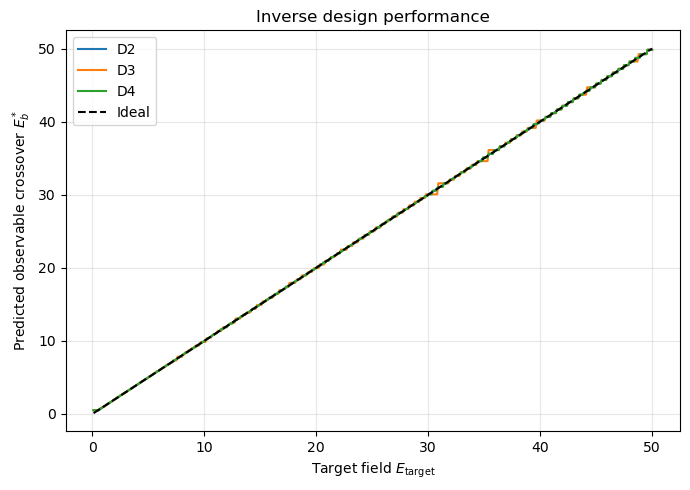

In [24]:
# ============================================================
# Plot predicted transition vs target
# ============================================================

plt.figure(figsize=(7, 5))

for sym in ["D2", "D3", "D4"]:
    sub = best_inverse_design_df[best_inverse_design_df["symmetry"] == sym]
    plt.plot(sub["target_Eb"], sub["Eb_weighted"], label=sym)

plt.plot(TARGETS, TARGETS, "k--", label="Ideal")
plt.xlabel(r"Target field $E_{\rm target}$")
plt.ylabel(r"Predicted observable crossover $E_b^*$")
plt.title("Inverse design performance")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(RESULTS_DIR / "inverse_design_predicted_vs_target.png", dpi=300)
plt.show()

In [25]:
import plotly.express as px
import numpy as np

plot3d_df = transition_df.copy()
plot3d_df = plot3d_df[plot3d_df["status"] == "ok"].copy()

plot3d_df = plot3d_df.dropna(
    subset=["D2_Eb_weighted", "D3_Eb_weighted", "D4_Eb_weighted"]
)

plot3d_df["mean_Eb"] = plot3d_df[
    ["D2_Eb_weighted", "D3_Eb_weighted", "D4_Eb_weighted"]
].mean(axis=1)

fig = px.scatter_3d(
    plot3d_df,
    x="D2_Eb_weighted",
    y="D3_Eb_weighted",
    z="D4_Eb_weighted",
    color="mean_Eb",
    hover_name="formula",
    hover_data={
        "B20": True,
        "B22": True,
        "B40": True,
        "B42": True,
        "B43": True,
        "B44": True,
        "D2_Eb_weighted": ":.3f",
        "D3_Eb_weighted": ":.3f",
        "D4_Eb_weighted": ":.3f",
        "mean_Eb": ":.3f",
    },
    title=r"3D map of observable transition fields across assumed symmetries",
    labels={
        "D2_Eb_weighted": r"$D_2: E_b^*$",
        "D3_Eb_weighted": r"$D_3: E_b^*$",
        "D4_Eb_weighted": r"$D_4: E_b^*$",
        "mean_Eb": r"Mean $E_b^*$",
    },
    width=900,
    height=750,
)

fig.update_traces(marker=dict(size=5, opacity=0.85))

fig.update_layout(
    scene=dict(
        xaxis_title=r"D2: E_b*",
        yaxis_title=r"D3: E_b*",
        zaxis_title=r"D4: E_b*",
    )
)

fig.show()

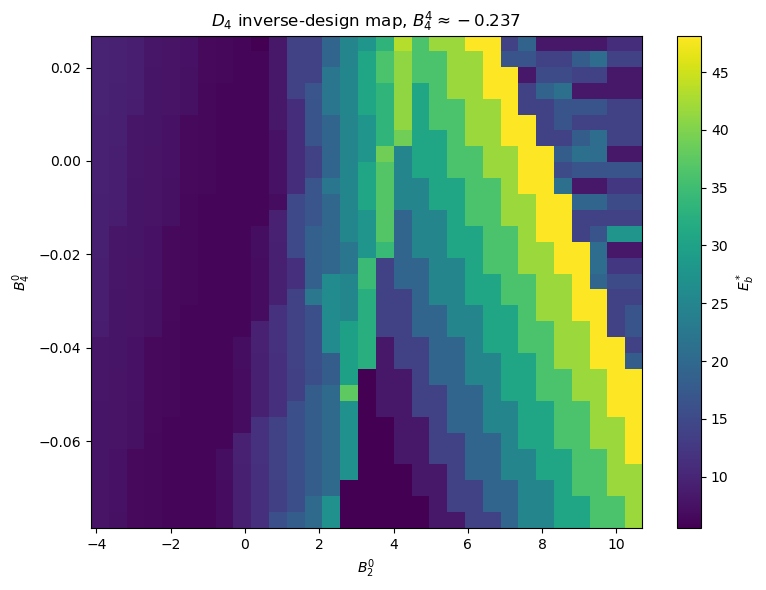

In [18]:
# ============================================================
# D4 heatmap: B20-B40 control of Eb*
# Use median/near-small B44 slice
# ============================================================

d4 = D4_scan_df.copy()

# choose B44 closest to median
B44_med = range_dict["B44"]["median"]
B44_unique = np.array(sorted(d4["B44"].dropna().unique()))
B44_slice = B44_unique[np.argmin(np.abs(B44_unique - B44_med))]

d4_slice = d4[np.isclose(d4["B44"], B44_slice)].copy()

pivot = d4_slice.pivot_table(
    index="B40",
    columns="B20",
    values="Eb_weighted"
)

plt.figure(figsize=(8, 6))
plt.imshow(
    pivot.values,
    origin="lower",
    aspect="auto",
    extent=[
        pivot.columns.min(), pivot.columns.max(),
        pivot.index.min(), pivot.index.max()
    ]
)

plt.colorbar(label=r"$E_b^*$")
plt.xlabel(r"$B_2^0$")
plt.ylabel(r"$B_4^0$")
plt.title(rf"$D_4$ inverse-design map, $B_4^4 \approx {B44_slice:.3g}$")
plt.tight_layout()

plt.savefig(RESULTS_DIR / "D4_B20_B40_inverse_design_heatmap.png", dpi=300)
plt.show()

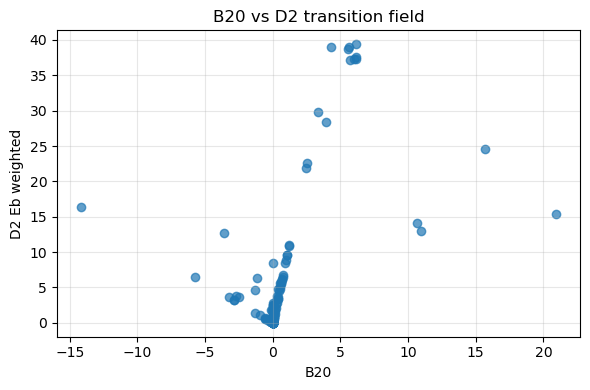

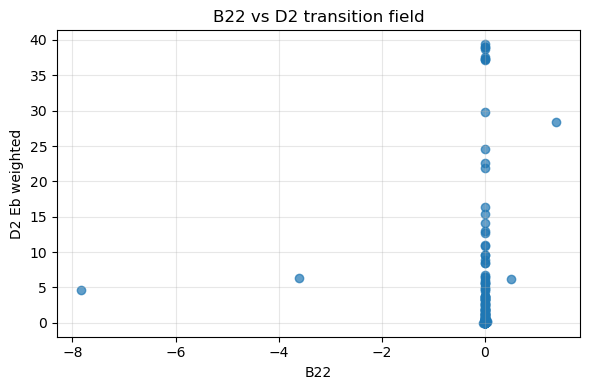

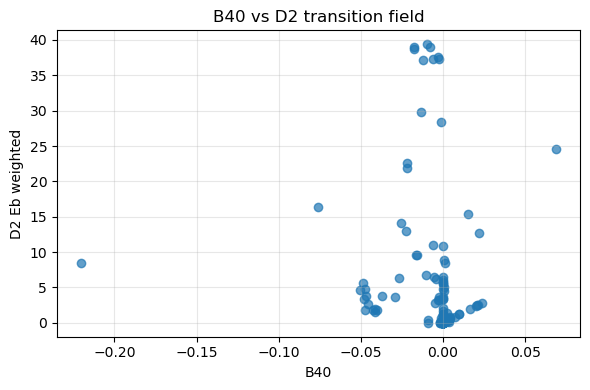

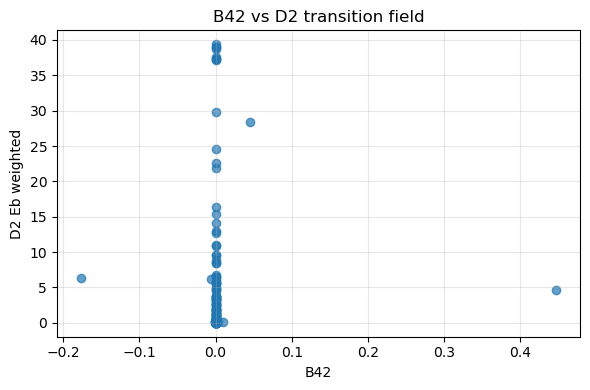

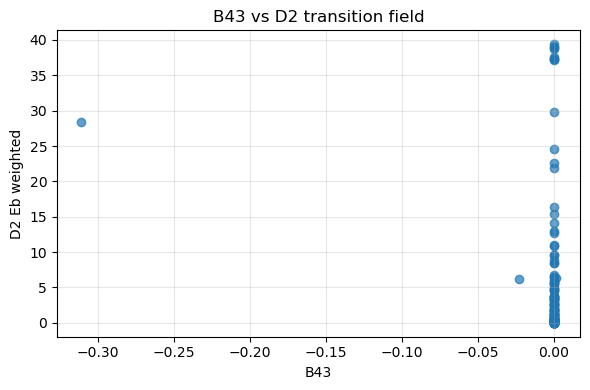

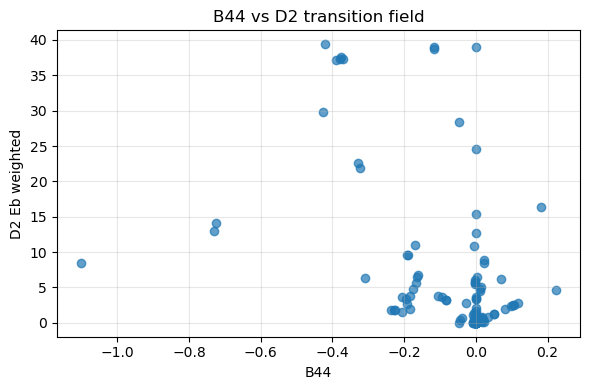

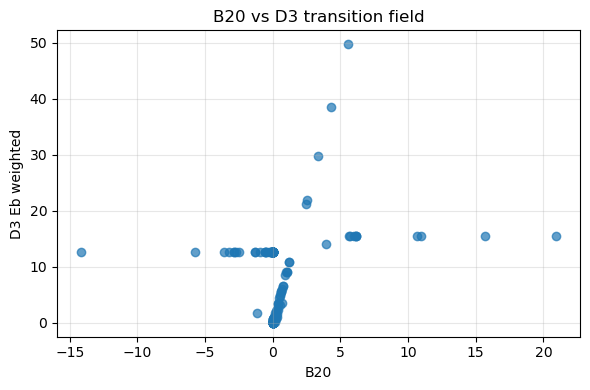

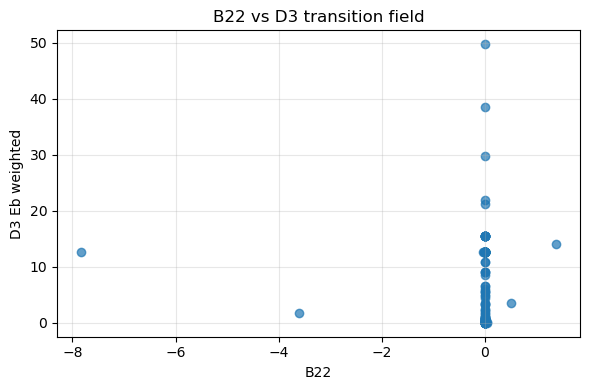

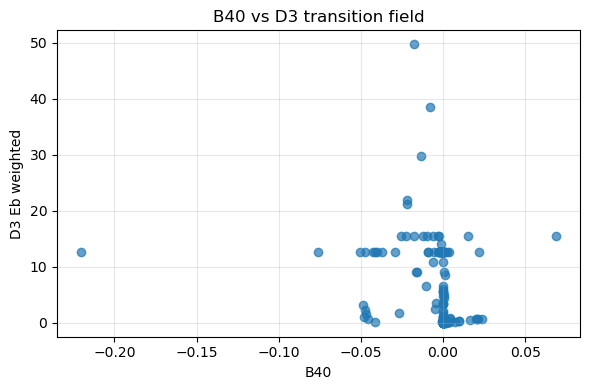

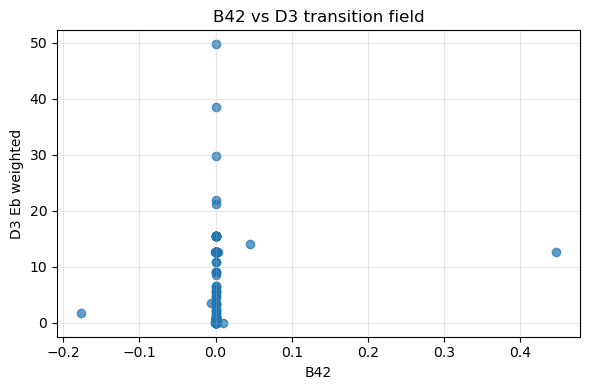

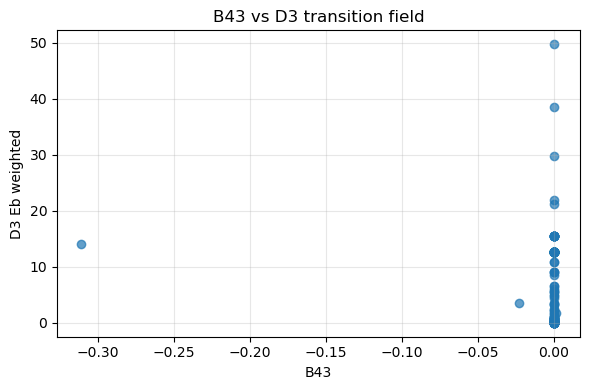

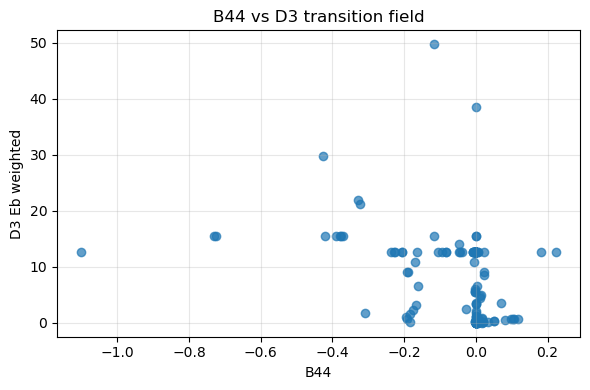

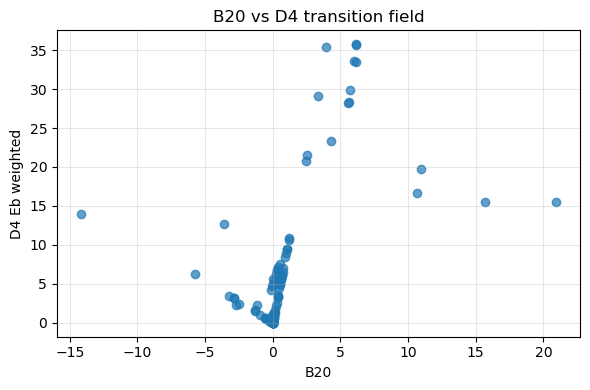

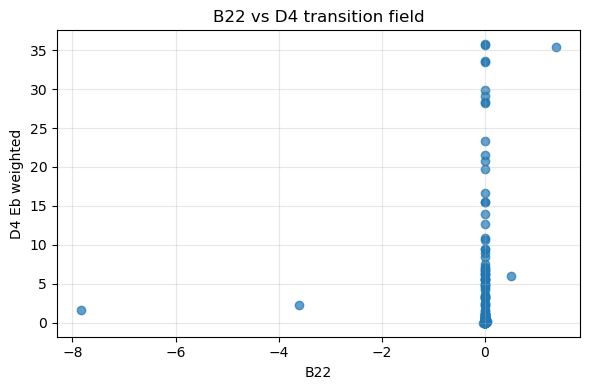

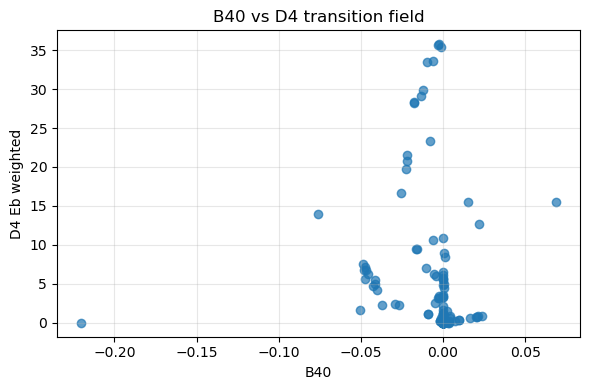

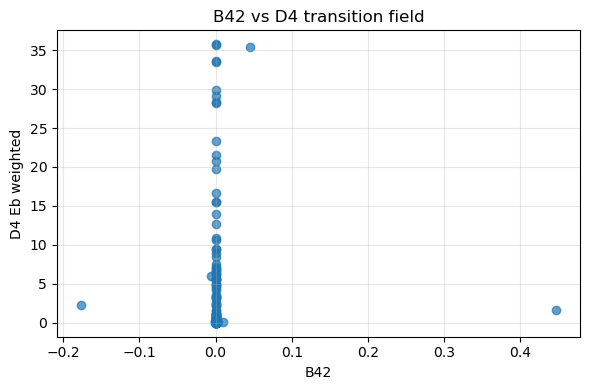

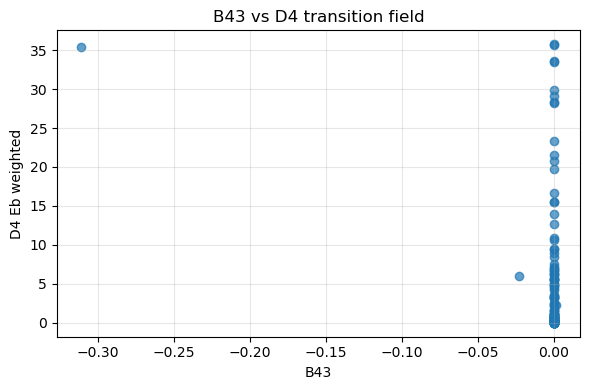

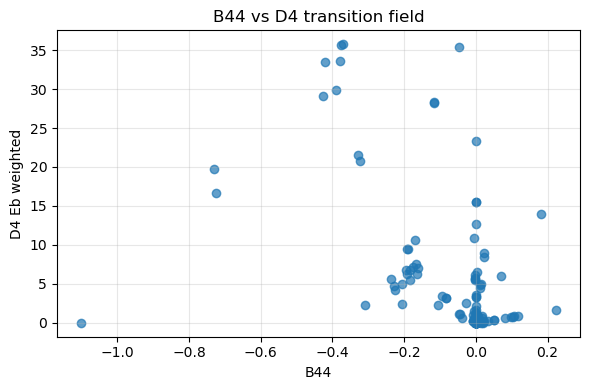

In [27]:
# ============================================================
# C1) Scatter plots: each Stevens parameter vs transition field
# ============================================================

for sym in sym_cols:
    for B in B_cols:
        sub = analysis_df[[B, sym, "formula"]].dropna()

        if len(sub) < 5:
            continue

        plt.figure(figsize=(6, 4))
        plt.scatter(sub[B], sub[sym], alpha=0.7)

        plt.xlabel(B)
        plt.ylabel(sym.replace("_", " "))
        plt.title(f"{B} vs {sym.replace('_Eb_weighted', '')} transition field")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        fname = RESULTS_DIR / f"scatter_{B}_vs_{sym}.png"
        plt.savefig(fname, dpi=300)
        plt.show()

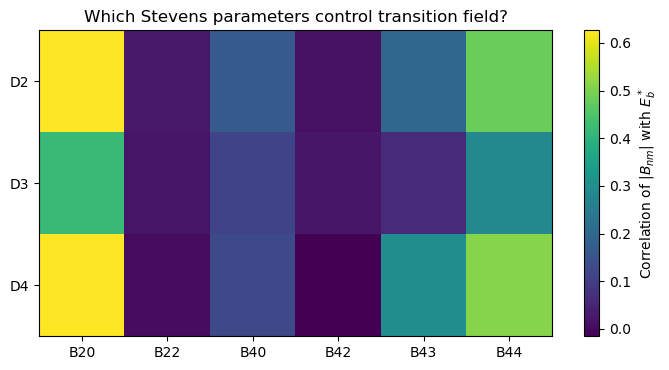

,B20,B22,B40,B42,B43,B44
D2,0.623998,0.027704,0.166450,0.012986,0.199633,0.481987
D3,0.417897,0.021825,0.114375,0.023921,0.061514,0.285925
D4,0.626204,0.005265,0.125203,-0.015405,0.299870,0.510742


In [28]:
# ============================================================
# C2) Heatmap-style correlation plot
# ============================================================

heatmap_data = []

for sym in sym_cols:
    row = {}
    for B in B_cols:
        sub = analysis_df[[B, sym]].dropna()

        if len(sub) < 5 or np.std(sub[B]) == 0:
            row[B] = np.nan
        else:
            row[B] = np.corrcoef(np.abs(sub[B]), sub[sym])[0, 1]

    heatmap_data.append(row)

heatmap_df = pd.DataFrame(
    heatmap_data,
    index=[s.replace("_Eb_weighted", "") for s in sym_cols]
)

plt.figure(figsize=(7, 3.8))
plt.imshow(heatmap_df.values, aspect="auto")
plt.colorbar(label=r"Correlation of $|B_{nm}|$ with $E_b^*$")

plt.xticks(range(len(B_cols)), B_cols)
plt.yticks(range(len(heatmap_df.index)), heatmap_df.index)

plt.title("Which Stevens parameters control transition field?")
plt.tight_layout()

plt.savefig(RESULTS_DIR / "stevens_transition_correlation_heatmap.png", dpi=300)
plt.show()

display(heatmap_df)

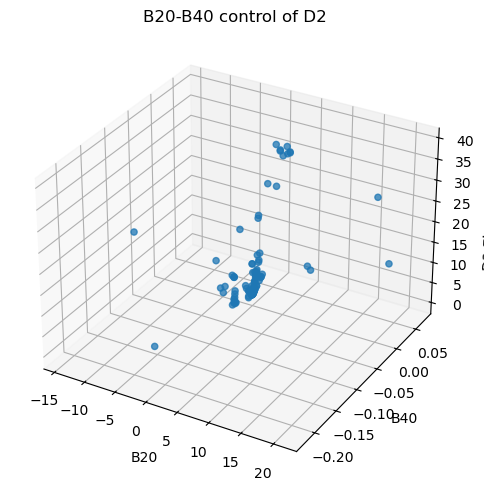

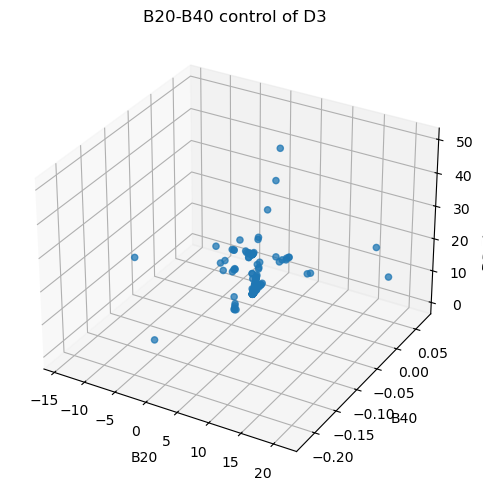

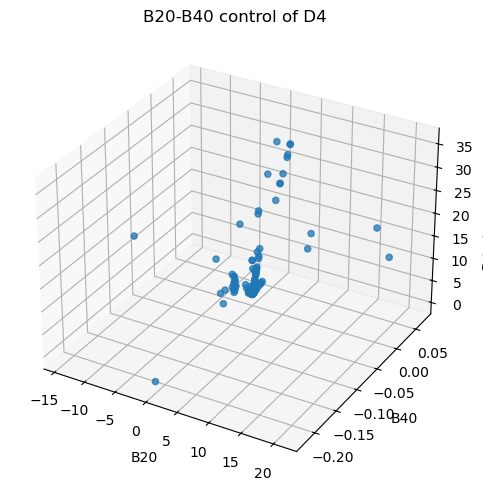

In [29]:
# ============================================================
# C3) 3D plot for the most important diagonal terms:
# B20, B40, transition field
# ============================================================

from mpl_toolkits.mplot3d import Axes3D

for sym in sym_cols:
    sub = analysis_df[["B20", "B40", sym, "formula"]].dropna()

    fig = plt.figure(figsize=(7, 5))
    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(sub["B20"], sub["B40"], sub[sym], alpha=0.75)

    ax.set_xlabel("B20")
    ax.set_ylabel("B40")
    ax.set_zlabel(sym.replace("_", " "))
    ax.set_title(f"B20-B40 control of {sym.replace('_Eb_weighted', '')}")

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"3d_B20_B40_{sym}.png", dpi=300)
    plt.show()

In [30]:
# ============================================================
# Compact summary: which parameters minimize Eb?
# Negative corr means increasing that parameter tends to lower Eb.
# Positive abs corr means larger magnitude strongly affects Eb.
# ============================================================

summary_rows = []

for sym in sym_cols:
    subcorr = corr_df[corr_df["symmetry"] == sym.replace("_Eb_weighted", "")].copy()

    if len(subcorr) == 0:
        continue

    strongest_abs = subcorr.iloc[subcorr["corr_absB_vs_Eb"].abs().argmax()]
    strongest_signed = subcorr.iloc[subcorr["corr_B_vs_Eb"].abs().argmax()]

    summary_rows.append({
        "symmetry": sym.replace("_Eb_weighted", ""),
        "strongest_by_magnitude": strongest_abs["parameter"],
        "corr_absB_vs_Eb": strongest_abs["corr_absB_vs_Eb"],
        "strongest_signed_parameter": strongest_signed["parameter"],
        "corr_B_vs_Eb": strongest_signed["corr_B_vs_Eb"],
    })

minimization_summary_df = pd.DataFrame(summary_rows)

display(minimization_summary_df)

minimization_summary_df.to_csv(
    RESULTS_DIR / "which_stevens_parameters_control_transition_field.csv",
    index=False
)

,symmetry,strongest_by_magnitude,corr_absB_vs_Eb,strongest_signed_parameter,corr_B_vs_Eb
0,D2,B20,0.623998,B20,0.524202
1,D3,B20,0.417897,B44,-0.323068
2,D4,B20,0.626204,B20,0.535264


In [44]:
def fmt_num(x, ndigits=5):
    if pd.isna(x):
        return None

    x = float(x)

    # Force tiny values to exact zero
    if abs(x) < 1e-10:
        return "0"

    s = f"{x:.{ndigits}f}"

    # Remove trailing zeros
    s = s.rstrip("0").rstrip(".")

    # Convert "-0" -> "0"
    if s == "-0":
        s = "0"

    return s


def fmt_transition(center, width, ndigits=5):

    if pd.isna(center) or pd.isna(width):
        return None

    center = float(center)
    width = float(width)

    if abs(center) < 1e-10:
        center_str = "0"
    else:
        center_str = f"{center:.{ndigits}f}".rstrip("0").rstrip(".")

    if abs(width) < 1e-10:
        width_str = "0"
    else:
        width_str = f"{width:.{ndigits}f}".rstrip("0").rstrip(".")

    if center_str == "-0":
        center_str = "0"

    if width_str == "-0":
        width_str = "0"

    return f"{center_str} ± {width_str}"


compact_rows = []

for _, row in transition_df.iterrows():

    out = {
        "formula": row.get("formula"),
        "status": row.get("status"),
    }

    # Stevens parameters
    for key in ["B20", "B22", "B40", "B42", "B43", "B44"]:

        val = fmt_num(row.get(key))

        if val is not None:
            out[key] = val

    # Transition fields
    d2 = fmt_transition(
        row.get("D2_Eb_weighted"),
        row.get("D2_Eb_width_std")
    )

    d3 = fmt_transition(
        row.get("D3_Eb_weighted"),
        row.get("D3_Eb_width_std")
    )

    d4 = fmt_transition(
        row.get("D4_Eb_weighted"),
        row.get("D4_Eb_width_std")
    )

    if d2 is not None:
        out["D2 transition field"] = d2

    if d3 is not None:
        out["D3 transition field"] = d3

    if d4 is not None:
        out["D4 transition field"] = d4

    compact_rows.append(out)

compact_transition_df = pd.DataFrame(compact_rows)

# Remove rows where all symmetry fields are missing
sym_cols = [
    c for c in compact_transition_df.columns
    if "transition field" in c
]

compact_transition_df = compact_transition_df.dropna(
    subset=sym_cols,
    how="all"
)

compact_transition_df.to_csv(
    RESULTS_DIR / "compact_transition_fields_with_stevens.csv",
    index=False
)

compact_transition_df

,formula,status,B20,B22,B40,B42,B43,B44,D2 transition field,D3 transition field,D4 transition field
0,CeIn3,ok,0,0,-0.04117,0,0,-0.20586,1.59327 ± 1.29398,12.73297 ± 12.66796,4.94249 ± 4.72493
1,CeCoIn5,ok,-0.0926,0,-0.04264,0,0,-0.22893,1.78675 ± 1.45197,12.73297 ± 12.66796,4.76602 ± 4.24653
2,CeRhIn5,ok,0.32098,0,-0.04678,0,0,-0.18373,3.77644 ± 0.00125,1.48632 ± 0.00125,6.72332 ± 7.39585
3,CeIrIn5,ok,0.41785,0,-0.04769,0,0,-0.17429,4.77649 ± 0.00125,2.32887 ± 0.00125,7.17984 ± 8.08268
4,Ce2CoIn8,ok,-0.14673,0,-0.03993,0,0,-0.22684,1.77494 ± 1.44255,12.73297 ± 12.66796,4.21135 ± 3.5253
...,...,...,...,...,...,...,...,...,...,...,...
89,CePdAl3,ok,6.88343,0,-0.03227,0,-0.1187,-0.66806,49.81374 ± 0.00125,0.00375 ± 0.00125,30.10776 ± 0.00125
90,CePtAl3,ok,6.93015,0,-0.03376,0,-0.11578,-0.69235,14.34164 ± 16.08881,0.00375 ± 0.00125,29.82774 ± 0.00125
91,CeNiAl4,ok,2.34029,-3.99134,-0.07987,0.32135,0,-0.18343,26.12317 ± 3.49116,18.66718 ± 0.00125,19.1624 ± 23.17075
93,CeRu2Al10,ok,-0.80348,3.98854,0.02318,-0.15488,0,0.24107,3.47419 ± 2.63162,12.73297 ± 12.66796,2.04757 ± 1.67008


In [45]:
# Export compact_transition_df to LaTeX table

latex_df = compact_transition_df.copy()

# Optional: rename columns for paper formatting
latex_df = latex_df.rename(columns={
    "formula": "Compound",
    "status": "Status",
    "B20": r"$B_2^0$",
    "B22": r"$B_2^2$",
    "B40": r"$B_4^0$",
    "B42": r"$B_4^2$",
    "B43": r"$B_4^3$",
    "B44": r"$B_4^4$",
    "D2 transition field": r"$D_2$: $E_b^*$",
    "D3 transition field": r"$D_3$: $E_b^*$",
    "D4 transition field": r"$D_4$: $E_b^*$",
})

latex_table = latex_df.to_latex(
    index=False,
    escape=False,
    caption=(
        r"Estimated field-induced crystal-field crossover energies $E_b^*$ "
        r"for each compound under assumed $D_2$, $D_3$, and $D_4$ symmetries."
    ),
    label="tab:transition_fields",
    column_format="l l r r r r r r c c c"
)

out_path = RESULTS_DIR / "compact_transition_fields_with_stevens.tex"

with open(out_path, "w") as f:
    f.write(latex_table)

print(f"Saved LaTeX table to: {out_path}")
print(latex_table)

Saved LaTeX table to: results/compact_transition_fields_with_stevens.tex
\begin{table}
\caption{Estimated field-induced crystal-field crossover energies $E_b^*$ for each compound under assumed $D_2$, $D_3$, and $D_4$ symmetries.}
\label{tab:transition_fields}
\begin{tabular}{l l r r r r r r c c c}
\toprule
Compound & Status & $B_2^0$ & $B_2^2$ & $B_4^0$ & $B_4^2$ & $B_4^3$ & $B_4^4$ & $D_2$: $E_b^*$ & $D_3$: $E_b^*$ & $D_4$: $E_b^*$ \\
\midrule
CeIn3 & ok & 0 & 0 & -0.04117 & 0 & 0 & -0.20586 & 1.59327 ± 1.29398 & 12.73297 ± 12.66796 & 4.94249 ± 4.72493 \\
CeCoIn5 & ok & -0.0926 & 0 & -0.04264 & 0 & 0 & -0.22893 & 1.78675 ± 1.45197 & 12.73297 ± 12.66796 & 4.76602 ± 4.24653 \\
CeRhIn5 & ok & 0.32098 & 0 & -0.04678 & 0 & 0 & -0.18373 & 3.77644 ± 0.00125 & 1.48632 ± 0.00125 & 6.72332 ± 7.39585 \\
CeIrIn5 & ok & 0.41785 & 0 & -0.04769 & 0 & 0 & -0.17429 & 4.77649 ± 0.00125 & 2.32887 ± 0.00125 & 7.17984 ± 8.08268 \\
Ce2CoIn8 & ok & -0.14673 & 0 & -0.03993 & 0 & 0 & -0.22684 & 1.77494 ± 1.44

In [46]:
# Export compact_transition_df to LaTeX table
# Rounded to 3 significant figures

import math

latex_df = compact_transition_df.copy()

# ============================================================
# Helper: round to 3 significant figures
# ============================================================

def round_sig(x, sig=3):

    if x is None:
        return None

    try:
        x = float(x)
    except:
        return x

    if x == 0:
        return "0"

    return f"{x:.{sig}g}"


# ============================================================
# Round Stevens parameters
# ============================================================

stevens_cols = [
    "B20", "B22", "B40",
    "B42", "B43", "B44"
]

for col in stevens_cols:

    if col not in latex_df.columns:
        continue

    latex_df[col] = latex_df[col].apply(
        lambda x: round_sig(x, 3)
        if pd.notna(x)
        else ""
    )


# ============================================================
# Round transition fields
# ============================================================

transition_cols = [
    "D2 transition field",
    "D3 transition field",
    "D4 transition field",
]

def round_transition_string(s):

    if pd.isna(s) or s is None:
        return ""

    if "±" not in str(s):
        return s

    center, width = [v.strip() for v in str(s).split("±")]

    try:
        center = round_sig(float(center), 3)
    except:
        pass

    try:
        width = round_sig(float(width), 3)
    except:
        pass

    return f"{center} ± {width}"


for col in transition_cols:

    if col not in latex_df.columns:
        continue

    latex_df[col] = latex_df[col].apply(round_transition_string)


# ============================================================
# Rename columns for LaTeX formatting
# ============================================================

latex_df = latex_df.rename(columns={
    "formula": "Compound",
    "status": "Status",
    "B20": r"$B_2^0$",
    "B22": r"$B_2^2$",
    "B40": r"$B_4^0$",
    "B42": r"$B_4^2$",
    "B43": r"$B_4^3$",
    "B44": r"$B_4^4$",
    "D2 transition field": r"$D_2$: $E_b^*$",
    "D3 transition field": r"$D_3$: $E_b^*$",
    "D4 transition field": r"$D_4$: $E_b^*$",
})


# ============================================================
# Export LaTeX
# ============================================================

latex_table = latex_df.to_latex(
    index=False,
    escape=False,
    caption=(
        r"Estimated field-induced crystal-field crossover energies "
        r"$E_b^*$ for each compound under assumed "
        r"$D_2$, $D_3$, and $D_4$ symmetries."
    ),
    label="tab:transition_fields",
    column_format="l l r r r r r r c c c"
)

out_path = RESULTS_DIR / "compact_transition_fields_with_stevens.tex"

with open(out_path, "w") as f:
    f.write(latex_table)

print(f"Saved LaTeX table to: {out_path}")
print(latex_table)

Saved LaTeX table to: results/compact_transition_fields_with_stevens.tex
\begin{table}
\caption{Estimated field-induced crystal-field crossover energies $E_b^*$ for each compound under assumed $D_2$, $D_3$, and $D_4$ symmetries.}
\label{tab:transition_fields}
\begin{tabular}{l l r r r r r r c c c}
\toprule
Compound & Status & $B_2^0$ & $B_2^2$ & $B_4^0$ & $B_4^2$ & $B_4^3$ & $B_4^4$ & $D_2$: $E_b^*$ & $D_3$: $E_b^*$ & $D_4$: $E_b^*$ \\
\midrule
CeIn3 & ok & 0 & 0 & -0.0412 & 0 & 0 & -0.206 & 1.59 ± 1.29 & 12.7 ± 12.7 & 4.94 ± 4.72 \\
CeCoIn5 & ok & -0.0926 & 0 & -0.0426 & 0 & 0 & -0.229 & 1.79 ± 1.45 & 12.7 ± 12.7 & 4.77 ± 4.25 \\
CeRhIn5 & ok & 0.321 & 0 & -0.0468 & 0 & 0 & -0.184 & 3.78 ± 0.00125 & 1.49 ± 0.00125 & 6.72 ± 7.4 \\
CeIrIn5 & ok & 0.418 & 0 & -0.0477 & 0 & 0 & -0.174 & 4.78 ± 0.00125 & 2.33 ± 0.00125 & 7.18 ± 8.08 \\
Ce2CoIn8 & ok & -0.147 & 0 & -0.0399 & 0 & 0 & -0.227 & 1.77 ± 1.44 & 12.7 ± 12.7 & 4.21 ± 3.53 \\
Ce2RhIn8 & ok & 0.225 & 0 & -0.0454 & 0 & 0 & -0.193 & 2.

## 4. Field-energy formulas

The table reports candidate **bare crossing** fields and pairwise **avoided-crossing gap** estimates.

- \(D_2\): three coupled pairs in each 3-state block, with pairwise gaps \(2|P|,2|Q|,2|C|\).
- \(D_4\): one two-state mixed sector with gap \(2|C|\).
- \(D_3\): constructed from \(H=B_2^0O_2^0+B_4^0O_4^0+B_4^3O_4^3-E_bJ_z\), then candidate crossings are found from connected \(m_J\) states.

In [6]:
def finite_or_nan(x):
    try:
        x = float(x)
        return x if np.isfinite(x) else np.nan
    except Exception:
        return np.nan

def get_B(row, key, default=0.0):
    val = row.get(key, np.nan)
    return default if pd.isna(val) else finite_or_nan(val)

def positive_min(values):
    vals = [float(v) for v in values if np.isfinite(v) and float(v) > 0]
    return min(vals) if vals else np.nan

def d2_phase_scales(row):
    B20, B40, B22, B42, B44 = [get_B(row,k) for k in ["B20","B40","B22","B42","B44"]]
    A = 10*B20 + 60*B40
    D = -8*B20 + 120*B40
    F = -2*B20 - 180*B40
    P = np.sqrt(10)*B22 + 9*np.sqrt(10)*B42
    Q = 3*np.sqrt(2)*B22 - 15*np.sqrt(2)*B42
    C = 12*np.sqrt(5)*B44
    crossings = {
        "D2_Eb_AD_block1": (A-D)/2,
        "D2_Eb_AF_block1": (A-F)/4,
        "D2_Eb_DF_block1": (D-F)/2,
        "D2_Eb_AD_block2": (D-A)/2,
        "D2_Eb_AF_block2": (F-A)/4,
        "D2_Eb_DF_block2": (F-D)/2,
    }
    return {**crossings,
        "D2_min_positive_bare_Eb": positive_min(crossings.values()),
        "D2_gap_AD_approx": 2*abs(P),
        "D2_gap_AF_approx": 2*abs(C),
        "D2_gap_DF_approx": 2*abs(Q),
        "D2_min_pairwise_gap_approx": min(2*abs(P), 2*abs(C), 2*abs(Q))}

def d4_phase_scales(row):
    B20, B40, B44 = [get_B(row,k) for k in ["B20","B40","B44"]]
    A = 10*B20 - 60*B40
    F = -2*B20 + 180*B40
    C = 12*np.sqrt(5)*B44
    Eb1, Eb2 = (A-F)/4, (F-A)/4
    return {"D4_Eb_block1":Eb1, "D4_Eb_block2":Eb2,
            "D4_min_positive_bare_Eb":positive_min([Eb1,Eb2]), "D4_gap_min":2*abs(C)}

In [7]:
def J_matrices(J=2.5):
    m_vals = np.arange(J, -J-1, -1, dtype=float)
    n = len(m_vals)
    Jz = np.diag(m_vals)
    Jp = np.zeros((n,n), dtype=complex); Jm = np.zeros((n,n), dtype=complex)
    idx = {m:i for i,m in enumerate(m_vals)}
    for m in m_vals:
        if m+1 <= J: Jp[idx[m+1], idx[m]] = np.sqrt(J*(J+1)-m*(m+1))
        if m-1 >= -J: Jm[idx[m-1], idx[m]] = np.sqrt(J*(J+1)-m*(m-1))
    return m_vals, Jz, Jp, Jm

def stevens_operators_J52():
    J=2.5; m_vals,Jz,Jp,Jm = J_matrices(J); I=np.eye(len(m_vals), dtype=complex); X=J*(J+1)
    O20 = 3*np.linalg.matrix_power(Jz,2) - X*I
    O40 = 35*np.linalg.matrix_power(Jz,4) - (30*X-25)*np.linalg.matrix_power(Jz,2) + (3*X**2-6*X)*I
    O43 = 0.25*(Jz@(np.linalg.matrix_power(Jp,3)+np.linalg.matrix_power(Jm,3)) + (np.linalg.matrix_power(Jp,3)+np.linalg.matrix_power(Jm,3))@Jz)
    return m_vals, {"O20":O20, "O40":O40, "O43":O43}

def d3_phase_scales(row, tol=1e-12):
    B20, B40, B43 = [get_B(row,k) for k in ["B20","B40","B43"]]
    m_vals, ops = stevens_operators_J52()
    Hdiag = B20*ops["O20"] + B40*ops["O40"]
    Hoff = B43*ops["O43"]
    diag = np.real(np.diag(Hdiag))
    pairs = []
    for i in range(len(m_vals)):
        for j in range(i+1, len(m_vals)):
            V = Hoff[i,j]
            if abs(V) > tol:
                denom = m_vals[i] - m_vals[j]
                Eb_cross = (diag[i] - diag[j]) / denom
                pairs.append({"pair":f"m={m_vals[i]:g} ↔ {m_vals[j]:g}", "Eb":float(np.real(Eb_cross)), "gap_approx":float(2*abs(V))})
    return {"D3_pairs":json.dumps(pairs),
            "D3_min_positive_bare_Eb":positive_min([p["Eb"] for p in pairs]),
            "D3_min_pairwise_gap_approx":min([p["gap_approx"] for p in pairs], default=np.nan)}

## 5. Build final table

In [14]:
phase_rows=[]
for _, row in stevens_df.iterrows():
    rec = {"formula":row.get("formula"), "status":row.get("status")}
    for k in ["B20","B22","B40","B42","B43","B44"]: rec[k]=row.get(k,np.nan)
    for func, label in [(d2_phase_scales,"D2"),(d3_phase_scales,"D3"),(d4_phase_scales,"D4")]:
        try: rec.update(func(row))
        except Exception as exc: rec[f"{label}_error"] = repr(exc)
    phase_rows.append(rec)
final_df = pd.DataFrame(phase_rows)
final_df.to_csv(RESULTS_DIR / "compound_stevens_and_transition_fields.csv", index=False)
summary_cols = ["formula","status","B20","B22","B40","B42","B43","B44",
                "D2_min_positive_bare_Eb","D2_min_pairwise_gap_approx",
                "D3_min_positive_bare_Eb","D3_min_pairwise_gap_approx",
                "D4_min_positive_bare_Eb","D4_gap_min"]
summary_df = final_df[[c for c in summary_cols if c in final_df.columns]]
summary_df.to_csv(RESULTS_DIR / "summary_transition_field_table.csv", index=False)
summary_df

,formula,status,B20,B22,B40,B42,B43,B44,D2_min_positive_bare_Eb,D2_min_pairwise_gap_approx,D3_min_positive_bare_Eb,D3_min_pairwise_gap_approx,D4_min_positive_bare_Eb,D4_gap_min
0,CeIn3,ok,-0.000000,-0.000000e+00,-0.041173,-0.000000,-0.000000,-0.205863,1.235180,0.000000,NaN,NaN,2.470360,11.047784
1,CeCoIn5,ok,-0.092597,0.000000e+00,-0.042639,-0.000000,0.000000,-0.228928,0.445789,0.000000,NaN,NaN,2.280534,12.285552
2,CeRhIn5,ok,0.320984,0.000000e+00,-0.046779,-0.000000,-0.000000,-0.183726,1.843789,0.000000,NaN,NaN,3.769695,9.859748
3,CeIrIn5,ok,0.417847,0.000000e+00,-0.047693,-0.000000,-0.000000,-0.174289,1.608028,0.000000,NaN,NaN,4.115110,9.353320
4,Ce2RhIn8,ok,0.224942,0.000000e+00,-0.045363,-0.000000,-0.000000,-0.193139,2.046975,0.000000,NaN,NaN,3.396630,10.364908
5,Ce2IrIn8,ok,0.155752,0.000000e+00,-0.041303,-0.000000,-0.000000,-0.185098,2.010947,0.000000,NaN,NaN,2.945461,9.933388
6,CePt2In7,ok,0.284280,0.000000e+00,-0.047829,0.000000,-0.000000,-0.193808,2.016889,0.000000,NaN,NaN,3.722571,10.400823
7,Ce2CoAl7Ge4,no_cif,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,0.000000
8,Ce2IrAl7Ge4,no_cif,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,0.000000
9,Ce2NiAl7Ge4,no_cif,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,0.000000


## 6. Print LaTeX formulas used for D2/D4

In [ ]:
B20s,B40s,B22s,B42s,B44s = sp.symbols(r"B_2^0 B_4^0 B_2^2 B_4^2 B_4^4", real=True)
A2=10*B20s+60*B40s; D2=-8*B20s+120*B40s; F2=-2*B20s-180*B40s
P=sp.sqrt(10)*B22s+9*sp.sqrt(10)*B42s; Q=3*sp.sqrt(2)*B22s-15*sp.sqrt(2)*B42s; C=12*sp.sqrt(5)*B44s
A4=10*B20s-60*B40s; F4=-2*B20s+180*B40s
formulas={
"D2 Eb A-D block 1":sp.simplify((A2-D2)/2), "D2 Eb A-F block 1":sp.simplify((A2-F2)/4),
"D2 Eb D-F block 1":sp.simplify((D2-F2)/2), "D2 gap A-D":2*sp.Abs(P),
"D2 gap A-F":2*sp.Abs(C), "D2 gap D-F":2*sp.Abs(Q),
"D4 Eb block 1":sp.simplify((A4-F4)/4), "D4 gap":2*sp.Abs(C)}
for name, expr in formulas.items():
    print(f"% {name}\n{sp.latex(expr)}\n")

## 7. Interpretation reminders

- `bare_Eb` = where uncoupled diagonal levels would cross.
- `gap_approx` = local pairwise avoided-crossing gap from the direct off-diagonal coupling.
- For \(D_2\), the true problem is a coupled \(3\times3\) block, so pairwise gaps are local estimates.
- Field values are energy scales. To convert to Tesla, divide by the magnetic field-energy prefactor used in your definition of \(E_b\), such as \(g_J\mu_B\), if appropriate.